# 🏫 Pipeline de pré-processamento e modelagem, parte 2: o modelo da rede

O [desenv_03](desenv_03_pipeline_modelagem.ipynb) construiu o modelo pedido pelo enunciado, que prevê se cada aluno será alfabetizado, e mostrou o seu limite: todas as variáveis são iguais para os alunos da mesma rede no mesmo município, e nenhum modelo com elas distingue dois alunos da mesma rede. As mesmas variáveis, porém, descrevem bem a rede em que o aluno estuda.

Este notebook é a continuação do desenv_03, e troca o alvo. Em vez de prever se cada aluno será alfabetizado, prevê **se a rede em que ele estuda, no seu município, vai bater a meta nacional de 2024**, de 59,9% de crianças alfabetizadas. A saída continua probabilística: a probabilidade de a rede bater a meta.

📌 **A distância do enunciado, declarada.** O enunciado pede a previsão do aluno. O foco continua nele, mas a previsão e a ação acontecem na rede em que ele estuda, que é onde os dados têm informação e onde a política pública atua: formação de professores, oferta de pré-escola, apoio às escolas. É também nesse nível que as perguntas de negócio do enunciado são respondidas: municípios em risco, metas não atingidas e fatores de maior impacto.

> **Convenção de trabalho:** o desenvolvimento acontece neste notebook, célula a célula, com os resultados salvos. Ao final da etapa, o código estável é promovido para `src/modeling/`, junto com o do desenv_03.

**Decisões que governam este notebook** (ver [diário de decisões](../docs/decisoes.md)): D-010 e D-011, as variáveis herdadas do desenv_03 e o tratamento de cada uma; D-013, o alvo na rede; e D-015, a curadoria das variáveis, que as reduz a 14, a entrada da UF e da região no modelo como ponto de partida, e a escolha do modelo.

---

## Roteiro

| Seção | Etapa | O que responde |
|---|---|---|
| 1 | Dados | uma linha por rede em cada município, e se ela bateu a meta de 2024 |
| 2 | Curadoria das variáveis | qual variável representa cada tema, com critério e motivo |
| 3 | Modelos no nível da rede | referências, três famílias de modelos, a escolha e a comparação com o modelo de aluno |
| 4 | Avaliação no teste | quanto o modelo acerta em municípios que nenhuma etapa viu, no geral e por recorte |

A análise do modelo pronto, com os fatores que pesam, as redes em risco e as respostas às perguntas do enunciado, fica no [desenv_05](desenv_05_aplicacao_estrategica.ipynb).

A validação segue o desenho do desenv_03: validação cruzada em cinco partes agrupadas por município dentro do treino, para escolher; a partição de validação, para confirmar; e a de teste, aberta só na seção 4.

## 1. Dados

**Passos desta seção:** (1.1) configurar o acesso ao data lake; (1.2) carregar a base e a lista de variáveis; (1.3) montar a base das redes; (1.4) reconstruir o pipeline.

**A resposta.** A taxa de alfabetização de cada rede é calculada com o peso amostral do INEP, como a taxa oficial. A rede **bateu a meta** quando essa taxa é de 59,9% ou mais.

**Cada rede pesa igual.** A rede é a unidade de decisão da política pública, e por isso, no treino e na medida principal, uma rede de 20 alunos pesa o mesmo que uma de 50 mil. A AUC ponderada pelo número de alunos entra só na escolha do modelo, na seção 2.

⚠️ **As redes pequenas.** A taxa de uma rede com poucos alunos oscila muito de um ano para outro, e a resposta dela é, em parte, sorte da amostra. Elas entram no modelo, porque existem e precisam de previsão, e as seções 2 e 3 medem à parte o desempenho só nas redes com 20 alunos ou mais.

In [71]:
# --- 1.1 Configuração e acesso ao data lake ---
import io
import json
import os
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pydata_google_auth
from google.cloud import storage

warnings.filterwarnings("ignore")
# os processos auxiliares do joblib não herdam o filtro acima; a variável
# de ambiente vale também para eles
os.environ["PYTHONWARNINGS"] = "ignore"
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 170)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9,
                     "axes.spines.top": False, "axes.spines.right": False})

CFG = json.loads(Path("../config/config.json").read_text(encoding="utf-8"))
PROJETO_GCP = CFG["projeto_gcp"]
BUCKET_LAKE = CFG["bucket_lake"]

ESCOPOS = ["https://www.googleapis.com/auth/cloud-platform"]
credenciais = pydata_google_auth.get_user_credentials(ESCOPOS)
credenciais = credenciais.with_quota_project(PROJETO_GCP)
cliente_storage = storage.Client(project=PROJETO_GCP, credentials=credenciais)


def ler_lake(area: str, tabela: str) -> pd.DataFrame:
    """Lê a partição mais recente de uma tabela do lake, a partir da memória."""
    particoes = sorted({
        b.name.split("/")[2]
        for b in cliente_storage.list_blobs(BUCKET_LAKE, prefix=f"{area}/{tabela}/")
        if len(b.name.split("/")) > 2
    })
    if not particoes:
        raise FileNotFoundError(
            f"Tabela '{tabela}' não encontrada em {area}/. "
            "Execute antes o notebook desenv_01_base_analitica.")
    caminho = f"{area}/{tabela}/{particoes[-1]}/{tabela}.parquet"
    blob = cliente_storage.bucket(BUCKET_LAKE).blob(caminho)
    print(f"  lendo {caminho}")
    return pd.read_parquet(io.BytesIO(blob.download_as_bytes()))


print(f"Lake: gs://{BUCKET_LAKE}/")
print("Setup ok")

Lake: gs://tech-challenge-fase2-lake-rm373453/
Setup ok


In [72]:
# --- 1.2 Carregar a base e a lista de variáveis ---
abt = ler_lake("ml", "abt_alfabetizacao")
lista = pd.read_csv("../reports/variaveis_modelagem.csv", index_col="variavel")
modelo_aluno = json.loads(Path("../reports/modelo_escolhido.json").read_text(encoding="utf-8"))

entram = lista[lista["situacao"] == "entra"]
CATEGORICAS = entram.index[entram["tipo"] == "categórica"].tolist()
NUMERICAS = entram.index[entram["tipo"] == "numérica"].tolist()
VARIAVEIS = NUMERICAS + CATEGORICAS
# UF e região ficam fora da seleção de variáveis da seção 2 e entram no modelo final,
# na seção 3, como ponto de partida, a exemplo da inércia (D-015).
TERRITORIO = ["sigla_uf", "nome_regiao"]
VARIAVEIS_MODELO = [v for v in VARIAVEIS if v not in TERRITORIO]
faltam = [v for v in VARIAVEIS + ["peso_aluno"] if v not in abt.columns]
if faltam:
    raise RuntimeError(f"Colunas ausentes na base: {faltam}")

privada = abt["rede_nome"] == "Privada"   # fora da modelagem (D-011)
abt = abt.loc[~privada, ["particao", "id_municipio", "alvo", "peso_aluno"] + VARIAVEIS].copy()
print(f"Variáveis na tabela: {len(VARIAVEIS)}   ·   no modelo: {len(VARIAVEIS_MODELO)}   ·   "
      f"rede privada retirada: {int(privada.sum())} alunos")

  lendo ml/abt_alfabetizacao/data_processamento=2026-09-14/abt_alfabetizacao.parquet
Variáveis na tabela: 43   ·   no modelo: 41   ·   rede privada retirada: 24 alunos


In [73]:
# --- 1.3 Uma linha por rede em cada município ---
META_2024, META_2030 = 59.9, 80.0   # metas nacionais pactuadas, rede pública
MIN_ALUNOS_ESTAVEL = 20             # abaixo disso, a taxa da rede oscila por tamanho de amostra
CHAVE = ["particao", "id_municipio", "rede_nome"]

# Trava: dentro de cada rede, nenhuma variável pode variar entre os alunos
variacao = (abt.groupby(CHAVE, observed=True)[NUMERICAS + ["sigla_uf", "nome_regiao"]]
            .nunique(dropna=False).max())
if (variacao > 1).any():
    raise RuntimeError(f"Variáveis que variam dentro da rede: {variacao[variacao > 1].to_dict()}")

abt["peso_alfabetizados"] = abt["peso_aluno"] * abt["alvo"]
redes = (abt.groupby(CHAVE, observed=True)
         .agg(alunos=("alvo", "size"), alfabetizados=("alvo", "sum"),
              peso_total=("peso_aluno", "sum"),
              peso_alfabetizados=("peso_alfabetizados", "sum"),
              **{v: (v, "first") for v in NUMERICAS + ["sigla_uf", "nome_regiao"]})
         .reset_index())
redes["taxa_real"] = 100 * redes["peso_alfabetizados"] / redes["peso_total"]
redes["bateu_meta"] = (redes["taxa_real"] >= META_2024).astype(int)
if redes["alunos"].sum() != len(abt):
    raise RuntimeError("A base das redes não soma os alunos da base.")


def separar_redes(particoes: list):
    """Variáveis, resposta, alunos e município das redes das partições pedidas."""
    d = redes[redes["particao"].isin(particoes)]
    return d[VARIAVEIS], d["bateu_meta"], d["alunos"], d["id_municipio"]


Xr_treino, yr_treino, alunos_treino, municipio_treino = separar_redes(["treino"])
Xr_validacao, yr_validacao, alunos_validacao, _ = separar_redes(["validacao"])
Xr_final, yr_final, alunos_final, _ = separar_redes(["treino", "validacao"])
Xr_teste, yr_teste, alunos_teste, municipio_teste = separar_redes(["teste"])

resumo = (redes.groupby("particao")
          .agg(redes=("bateu_meta", "size"), bateram_pct=("bateu_meta", "mean"),
               alunos=("alunos", "sum"),
               pequenas_pct=("alunos", lambda s: (s < MIN_ALUNOS_ESTAVEL).mean()))
          .reindex(["treino", "validacao", "teste"]))
resumo[["bateram_pct", "pequenas_pct"]] = (100 * resumo[["bateram_pct", "pequenas_pct"]]).round(1)
print(f"REDES POR PARTIÇÃO (meta de {META_2024}%; pequenas = menos de {MIN_ALUNOS_ESTAVEL} alunos)")
print(resumo.to_string())

REDES POR PARTIÇÃO (meta de 59.9%; pequenas = menos de 20 alunos)
           redes  bateram_pct   alunos  pequenas_pct
particao                                            
treino      3893         57.3  1156013           7.6
validacao   1312         56.6   384021           8.9
teste       1330         57.0   311794           8.5


In [74]:
# --- 1.4 Pipeline: definições da seção 2.1 do desenv_03, sem alteração ---
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler


class PreparadorAusencias(BaseEstimator, TransformerMixin):
    """Cria os indicadores de ausência e imputa pela mediana da UF.

    As medianas são aprendidas no fit, só com os dados de treino, e
    aplicadas no transform. A UF sem valor para uma variável recebe a
    mediana nacional.
    """

    def __init__(self, numericas: list, indicadores: dict, coluna_uf: str = "sigla_uf"):
        self.numericas = numericas
        self.indicadores = indicadores
        self.coluna_uf = coluna_uf

    def fit(self, X, y=None):
        valores = X[self.numericas].astype("float64")
        self.medianas_uf_ = valores.groupby(X[self.coluna_uf]).median()
        self.medianas_nacionais_ = valores.median()
        return self

    def transform(self, X):
        X = X.copy()
        # os indicadores vêm antes da imputação, que apaga o sinal da ausência
        for nome, variavel in self.indicadores.items():
            X[nome] = X[variavel].isna().astype("int64")
        valores = X[self.numericas].astype("float64")
        da_uf = self.medianas_uf_.reindex(X[self.coluna_uf]).set_index(X.index)
        X[self.numericas] = valores.fillna(da_uf).fillna(self.medianas_nacionais_)
        return X


# O que a lista da análise exploratória determina
INDICADORES = {nome: variavel for variavel, nome
               in entram["indicador_ausencia"].dropna().items()}
COM_LOG = entram.index[entram["transformacao"].notna()].tolist()


def montar_preprocessamento(linear: bool, variaveis: list | None = None) -> Pipeline:
    """Pré-processamento completo; linear=True acrescenta logaritmo e padronização.

    variaveis restringe o pré-processamento a um subconjunto da lista, o que a
    seção 4 usa para comparar blocos de hipótese; por padrão, usa todas.
    """
    usar = set(variaveis or VARIAVEIS)
    numericas = [v for v in NUMERICAS if v in usar]
    categoricas = [v for v in CATEGORICAS if v in usar]
    indicadores = {n: v for n, v in INDICADORES.items() if v in usar}
    com_log = [v for v in COM_LOG if v in usar]
    sem_log = [v for v in numericas if v not in com_log] + list(indicadores)
    if linear:
        passos = [("log", Pipeline([
                      ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
                      ("escala", StandardScaler())]), com_log),
                  ("numericas", StandardScaler(), sem_log)]
    else:
        passos = [("numericas", "passthrough", com_log + sem_log)]
    passos.append(("categoricas",
                   OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                   categoricas))
    colunas = ColumnTransformer(passos, verbose_feature_names_out=False)
    colunas.set_output(transform="pandas")
    return Pipeline([("ausencias", PreparadorAusencias(numericas, indicadores)),
                     ("colunas", colunas)])


print(f"Indicadores de ausência: {', '.join(f'{n} ({v})' for n, v in INDICADORES.items())}")
print(f"Logaritmo, só no linear: {', '.join(COM_LOG)}")
print(f"One-hot: {', '.join(CATEGORICAS)}")


def montar_modelo(estimador, linear: bool, variaveis: list | None = None) -> Pipeline:
    """Pré-processamento e modelo num único pipeline."""
    return Pipeline([("preparo", montar_preprocessamento(linear, variaveis)),
                     ("modelo", estimador)])


from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score


def medir(y, p, w=None) -> dict:
    """AUC, log-loss e Brier; sem pesos, cada rede pesa igual."""
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return {"auc": roc_auc_score(y, p, sample_weight=w),
            "log_loss": log_loss(y, p, sample_weight=w),
            "brier": brier_score_loss(y, p, sample_weight=w)}

Indicadores de ausência: sem_rede_ant (rede_taxa_ant), sem_municipio_ant (rede_vs_municipio), sem_microdados_ant (mun_participacao_ant), sem_meta (mun_gap_meta)
Logaritmo, só no linear: esc_pct_area_diferenciada, mun_pib_per_capita, mun_populacao, mun_densidade_demografica, mun_pct_vulner_deslocamento_1h
One-hot: rede_nome, sigla_uf, nome_regiao


## 2. Curadoria das variáveis

As 43 variáveis vieram do desenv_02 (D-010), escolhidas uma a uma por hipótese, no grão do aluno. Duas delas, a UF e a região, **ficam fora desta seleção**: elas não mudam de um ano para o outro e funcionam como a inércia, como ponto de partida de cada rede, e por isso entram no modelo final por decisão, na seção 3 (D-015). A seleção trabalha com as outras 41. Com o alvo na rede, elas precisam ser revistas: várias medem o mesmo tema com pequenas variações, e um modelo com versões repetidas do mesmo tema divide o crédito entre elas e fica difícil de explicar.

**O princípio: um tema, uma variável.** Cada tema é um conceito que pode explicar por que uma rede cumpre ou não a meta. Para cada tema, fica a variável que melhor o representa.

**Os critérios de escolha, nesta ordem:**

1. **não ser combinação exata de outras:** uma diferença ou razão entre variáveis que já estão no modelo não acrescenta informação, só divide o crédito;
2. **o grão mais próximo da criança:** entre uma medida da rede e uma do município para o mesmo conceito, fica a da rede;
3. **a referência mais recente:** uma fonte de 2010 só fica se não houver substituta mais nova;
4. **cobertura:** menos valores ausentes;
5. **variação:** uma variável em que quase todas as redes têm o mesmo valor não distingue ninguém;
6. **leitura clara para o gestor:** o que ela mede e quem pode mexer nela.

**Passos desta seção:** (2.1) montar a evidência de cada tema; (2.2) registrar a escolha e o motivo.

⚠️ **Toda a evidência usa só a partição de treino.** A escolha das variáveis faz parte da modelagem e não pode enxergar a validação nem o teste.

In [75]:
# --- 2.1 A evidência de cada tema ---
from IPython.display import Markdown, display

DICIONARIO = pd.read_csv("../reports/dicionario_dados.csv", index_col="variavel")

# Os temas: cada um é um conceito, e reúne as variáveis que o medem
TEMAS = {
    "Desempenho em 2023 (ponto de partida)": ["rede_taxa_ant", "uf_rede_taxa_ant", "rede_vs_uf",
                                               "rede_vs_municipio", "mun_gap_meta"],
    "Qualidade da medição em 2023": ["mun_participacao_ant"],
    "Porte do município": ["mun_populacao", "mun_densidade_demografica"],
    "Peso da rede no município": ["rede_peso_no_municipio"],
    "Ruralidade e distância": ["esc_pct_rural", "esc_pct_transporte", "mun_pct_vulner_deslocamento_1h"],
    "Lotação": ["esc_alunos_por_sala", "turma_media_alunos", "esc_alunos_por_docente"],
    "Infraestrutura básica da escola": ["esc_pct_agua_rede", "esc_pct_esgoto_rede", "esc_pct_energia_rede",
                                        "esc_pct_alimentacao"],
    "Recursos pedagógicos": ["esc_pct_biblioteca_ou_sala_leitura", "esc_pct_lab_informatica",
                             "esc_pct_quadra", "esc_pct_internet"],
    "Corpo docente": ["esc_pct_docentes_formacao_adequada", "esc_pct_docentes_baixa_regularidade",
                      "esc_pct_docentes_alto_esforco"],
    "Tempo na escola": ["esc_horas_aula_diarias"],
    "Primeira infância": ["mun_indice_pre_escola", "mun_pct_maes_adolescentes"],
    "Nível socioeconômico das famílias": ["esc_inse_medio", "mun_pct_maes_8_anos_estudo",
                                          "mun_expectativa_estudo", "mun_ivs", "mun_gini"],
    "Economia do município": ["mun_pib_per_capita", "mun_pct_servicos"],
    "Saneamento do município": ["mun_pct_agua_rede_geral"],
    "Violência": ["mun_taxa_homicidio"],
    "Contexto linguístico e cultural": ["esc_pct_area_diferenciada"],
    "Perfil demográfico": ["mun_idade_mediana"],
    "Tipo de rede": ["rede_nome"],
}
# Trava: todo tema cobre só variáveis do modelo, e toda variável do modelo está em um tema só
nos_temas = [v for vs in TEMAS.values() for v in vs]
if sorted(nos_temas) != sorted(VARIAVEIS_MODELO):
    raise RuntimeError(f"Temas e modelo não batem: sobram {set(nos_temas) ^ set(VARIAVEIS_MODELO)}")

treino_redes = redes[redes["particao"] == "treino"]
numericas_modelo = [v for v in VARIAVEIS_MODELO if v in NUMERICAS]
correlacao = treino_redes[numericas_modelo].corr(method="spearman")


def grao(v: str) -> str:
    """De onde vem a medida: da rede, do município ou do estado."""
    return {"esc": "rede", "rede": "rede", "turma": "rede", "uf": "estado"}.get(v.split("_")[0], "município")


def numero(x: float, casas: int = 2) -> str:
    """Número no formato brasileiro, sem zeros sobrando à direita."""
    t = f"{x:,.{casas}f}".replace(",", "X").replace(".", ",").replace("X", ".")
    return t.rstrip("0").rstrip(",") if "," in t else t


def linha(v: str, tema: list) -> str:
    """Uma linha da tabela de evidência."""
    d = DICIONARIO.loc[v] if v in DICIONARIO.index else pd.Series(dtype=object)
    valores = treino_redes[v]
    ausentes = numero(100 * valores.isna().mean(), 1) + "%"
    if v in NUMERICAS:
        p25, p75 = valores.quantile([.25, .75])
        faixa = f"{numero(p25)} a {numero(p75)}"
        mais_comum = numero(100 * valores.value_counts(normalize=True).iloc[0], 0) + "%"
        no_tema = [f"{w} ({numero(correlacao.loc[v, w])})" for w in tema if w != v and w in NUMERICAS]
        fora = correlacao.loc[v].drop([w for w in tema if w in correlacao.columns]).abs()
        maior_fora = f"{fora.idxmax()} ({numero(correlacao.loc[v, fora.idxmax()])})"
    else:
        faixa, mais_comum, no_tema, maior_fora = "categórica", "", [], ""
    formula = d.get("formula", "")
    formula = formula if isinstance(formula, str) else ""
    return (f"| `{v}` | {d.get('descricao', '')} ({d.get('unidade', '')}) | {grao(v)} | {d.get('referencia', '')} "
            f"| {ausentes} | {faixa} | {mais_comum} | {'; '.join(no_tema)} | {maior_fora} | {formula} |")


CABECALHO = ("| Variável | O que mede | Grão | Ano | Ausentes | Faixa típica (p25 a p75) | Valor mais comum "
             "| Correlação com as outras do tema | Maior correlação fora do tema | Fórmula |\n"
             "|---|---|---|---|---|---|---|---|---|---|")
for tema, variaveis in TEMAS.items():
    display(Markdown(f"#### {tema} ({len(variaveis)} {'variável' if len(variaveis) == 1 else 'variáveis'})\n\n"
                     + CABECALHO + "\n" + "\n".join(linha(v, variaveis) for v in variaveis)))

print(f"Evidência calculada nas {len(treino_redes):,} redes do treino. Correlação de Spearman, que mede "
      "se as duas variáveis sobem e descem juntas, de -1 a 1.")

#### Desempenho em 2023 (ponto de partida) (5 variáveis)

| Variável | O que mede | Grão | Ano | Ausentes | Faixa típica (p25 a p75) | Valor mais comum | Correlação com as outras do tema | Maior correlação fora do tema | Fórmula |
|---|---|---|---|---|---|---|---|---|---|
| `rede_taxa_ant` | taxa de alfabetização da rede do aluno no município (% de alunos, de 0 a 100) | rede | 2023 | 1,4% | 47,19 a 75,96 | 1% | uf_rede_taxa_ant (0,59); rede_vs_uf (0,72); rede_vs_municipio (0,23); mun_gap_meta (-0,82) | mun_idade_mediana (0,33) |  |
| `uf_rede_taxa_ant` | benchmark: mediana da mesma rede entre os municípios da UF (% de alunos, de 0 a 100) | estado | 2023 | 1,4% | 56,43 a 73,83 | 13% | rede_taxa_ant (0,59); rede_vs_uf (-0,06); rede_vs_municipio (0,03); mun_gap_meta (-0,56) | esc_inse_medio (0,5) | mediana por UF e rede |
| `rede_vs_uf` | posição da rede diante do padrão do seu estado (pontos percentuais) | rede | 2023 | 1,4% | -9,86 a 9,27 | 0% | rede_taxa_ant (0,72); uf_rede_taxa_ant (-0,06); rede_vs_municipio (0,27); mun_gap_meta (-0,52) | mun_participacao_ant (0,19) | rede_taxa_ant - uf_rede_taxa_ant |
| `rede_vs_municipio` | posição da rede diante do seu município (pontos percentuais) | rede | 2023 | 10,1% | 0 a 0 | 66% | rede_taxa_ant (0,23); uf_rede_taxa_ant (0,03); rede_vs_uf (0,27); mun_gap_meta (0,02) | esc_alunos_por_sala (0,09) | rede_taxa_ant - mun_taxa_ant |
| `mun_gap_meta` | esforço requerido para atingir a meta (pontos percentuais) | município | 2023 e 2024 | 14,5% | -0,08 a 5,45 | 1% | rede_taxa_ant (-0,82); uf_rede_taxa_ant (-0,56); rede_vs_uf (-0,52); rede_vs_municipio (0,02) | mun_expectativa_estudo (-0,33) | mun_meta_ciclo - mun_taxa_ant |

#### Qualidade da medição em 2023 (1 variável)

| Variável | O que mede | Grão | Ano | Ausentes | Faixa típica (p25 a p75) | Valor mais comum | Correlação com as outras do tema | Maior correlação fora do tema | Fórmula |
|---|---|---|---|---|---|---|---|---|---|
| `mun_participacao_ant` | percentual de alunos presentes na avaliação anterior (% de alunos, de 0 a 100) | município | 2023 | 11,4% | 85,02 a 94,33 | 5% |  | rede_taxa_ant (0,23) |  |

#### Porte do município (2 variáveis)

| Variável | O que mede | Grão | Ano | Ausentes | Faixa típica (p25 a p75) | Valor mais comum | Correlação com as outras do tema | Maior correlação fora do tema | Fórmula |
|---|---|---|---|---|---|---|---|---|---|
| `mun_populacao` | população do município (habitantes) | município | 2021 | 0% | 5.801 a 28.433 | 0% | mun_densidade_demografica (0,47) | mun_pct_servicos (0,53) |  |
| `mun_densidade_demografica` | habitantes por quilômetro quadrado (habitantes por km²) | município | 2022 | 0% | 12 a 58,7 | 0% | mun_populacao (0,47) | mun_pct_servicos (0,58) | população / área |

#### Peso da rede no município (1 variável)

| Variável | O que mede | Grão | Ano | Ausentes | Faixa típica (p25 a p75) | Valor mais comum | Correlação com as outras do tema | Maior correlação fora do tema | Fórmula |
|---|---|---|---|---|---|---|---|---|---|
| `rede_peso_no_municipio` | fração dos alunos do município atendida pela rede (fração, de 0 a 1) | rede | 2024 | 0% | 0,8 a 1 | 70% |  | esc_pct_lab_informatica (-0,35) | rede_porte_atual / mun_porte_atual |

#### Ruralidade e distância (3 variáveis)

| Variável | O que mede | Grão | Ano | Ausentes | Faixa típica (p25 a p75) | Valor mais comum | Correlação com as outras do tema | Maior correlação fora do tema | Fórmula |
|---|---|---|---|---|---|---|---|---|---|
| `esc_pct_rural` | alunos do 2º ano que estudam em escolas de zona rural (% de alunos, de 0 a 100) | rede | 2023 | 0,1% | 0 a 36,4 | 33% | esc_pct_transporte (0,38); mun_pct_vulner_deslocamento_1h (0,33) | esc_pct_agua_rede (-0,6) | matriculas do 2º ano em escolas rurais / matriculas do 2º ano |
| `esc_pct_transporte` | dependência de transporte escolar, aproximação da distância entre aluno e escola (% de alunos) | rede | 2023 | 0% | 16,57 a 47,33 | 0% | esc_pct_rural (0,38); mun_pct_vulner_deslocamento_1h (0,01) | mun_pct_agua_rede_geral (-0,46) | alunos transportados / matrícula total da rede |
| `mun_pct_vulner_deslocamento_1h` | pessoas pobres que gastam mais de uma hora até o trabalho, aproximação das distâncias no território (% de pessoas, de 0 a 100) | município | 2010 | 0,1% | 0,3 a 1,77 | 7% | esc_pct_rural (0,33); esc_pct_transporte (0,01) | mun_ivs (0,82) |  |

...

#### Violência (1 variável)

| Variável | O que mede | Grão | Ano | Ausentes | Faixa típica (p25 a p75) | Valor mais comum | Correlação com as outras do tema | Maior correlação fora do tema | Fórmula |
|---|---|---|---|---|---|---|---|---|---|
| `mun_taxa_homicidio` | óbitos por agressão por cem mil habitantes, aproximação da exposição à violência (óbitos por 100 mil habitantes) | município | 2019 | 0% | 0 a 26,9 | 29% |  | mun_idade_mediana (-0,37) | óbitos CID X85 a Y09 * 100000 / população |

#### Contexto linguístico e cultural (1 variável)

| Variável | O que mede | Grão | Ano | Ausentes | Faixa típica (p25 a p75) | Valor mais comum | Correlação com as outras do tema | Maior correlação fora do tema | Fórmula |
|---|---|---|---|---|---|---|---|---|---|
| `esc_pct_area_diferenciada` | escolas em terra indígena, quilombo, assentamento ou comunidade tradicional (% de escolas, de 0 a 100) | rede | 2023 | 0% | 0 a 0,7 | 75% |  | mun_idade_mediana (-0,41) | escolas com código de área diferenciada diferente de zero / escolas em atividade |

#### Perfil demográfico (1 variável)

| Variável | O que mede | Grão | Ano | Ausentes | Faixa típica (p25 a p75) | Valor mais comum | Correlação com as outras do tema | Maior correlação fora do tema | Fórmula |
|---|---|---|---|---|---|---|---|---|---|
| `mun_idade_mediana` | idade mediana da população (anos) | município | 2022 | 0% | 33 a 38 | 10% |  | mun_ivs (-0,61) |  |

#### Tipo de rede (1 variável)

| Variável | O que mede | Grão | Ano | Ausentes | Faixa típica (p25 a p75) | Valor mais comum | Correlação com as outras do tema | Maior correlação fora do tema | Fórmula |
|---|---|---|---|---|---|---|---|---|---|
| `rede_nome` | rede de ensino que atende o aluno (categoria: Estadual, Municipal, Privada) | rede | 2024 | 0% | categórica |  |  |  |  |

Evidência calculada nas 3,893 redes do treino. Correlação de Spearman, que mede se as duas variáveis sobem e descem juntas, de -1 a 1.


**Como ler as tabelas.** Cada tema traz as suas candidatas, e cada coluna responde a um dos critérios:

- **Fórmula:** se a variável é calculada a partir de outras. Uma diferença entre duas variáveis do modelo é combinação exata (critério 1);
- **Grão e Ano:** critérios 2 e 3;
- **Ausentes:** critério 4;
- **Faixa típica e Valor mais comum:** critério 5. Se o valor mais comum reúne quase todas as redes, a variável quase não varia;
- **Correlação com as outras do tema:** acima de 0,8 em módulo, as duas carregam quase a mesma informação, e basta uma;
- **Maior correlação fora do tema:** mostra quando uma variável repete um tema vizinho, o que também é redundância.

A escolha de cada tema é registrada na 2.2, depois desta evidência.

### 2.2 Etapa A: tirar o que é redundante, sem olhar a resposta

A seleção das variáveis tem duas etapas. Esta primeira aplica filtros que **não usam a resposta**: eles olham só as próprias variáveis, e por isso não correm o risco de escolher o que por acaso acerta no treino. A segunda etapa, na 2.3, mede quanto cada variável que sobrou ajuda a prever.

**As regras, aplicadas nesta ordem, com os limites declarados antes de rodar:**

| # | Regra | Limite | Por quê |
|---|---|---|---|
| 1 | variável com muitos ausentes | mais de 20% das redes sem valor | a imputação passaria a inventar mais do que medir |
| 2 | variável que quase não varia | o valor mais comum reúne 90% das redes ou mais | se quase todas as redes têm o mesmo valor, ela não distingue ninguém |
| 3 | variável explicada pelas outras juntas | VIF acima de 10 | pega combinações de várias variáveis, como uma diferença entre duas outras |
| 4 | par de variáveis quase iguais | correlação acima de 0,8, em módulo | as duas carregam a mesma informação, e basta uma |

🎓 **Conceito, VIF.** O fator de inflação da variância mede quanto uma variável pode ser prevista por todas as outras juntas. Um VIF de 10 quer dizer que 90% da variação dela já está nas outras. Ele pega o que a comparação de duas em duas não pega: a posição da rede diante da UF, por exemplo, é a diferença exata entre a taxa da rede e a taxa da UF, e o VIF dela é praticamente infinito.

**Quando duas variáveis empatam numa regra, qual sai.** Nas regras 3 e 4, sai primeiro a que for, nesta ordem:

1. calculada a partir de outras variáveis do modelo;
2. do grão do município ou do estado, e não da rede;
3. de referência mais antiga;
4. com mais valores ausentes.

Todas as contas usam só a partição de treino.

In [77]:
# --- 2.2 Etapa A: tirar o que é redundante, sem olhar a resposta ---
import re

LIMITE_AUSENTES = 0.20       # fração de redes sem valor
LIMITE_CONSTANTE = 0.90      # fração de redes no valor mais comum
LIMITE_VIF = 10.0
LIMITE_CORRELACAO = 0.80     # em módulo, Spearman

candidatas = [v for v in VARIAVEIS_MODELO if v in NUMERICAS]


def ano(v: str) -> int:
    """O ano mais recente citado na referência da variável."""
    anos = [int(a) for a in re.findall(r"(?:19|20)\d{2}", str(DICIONARIO.loc[v, "referencia"]))] \
        if v in DICIONARIO.index else []
    return max(anos) if anos else 0


def derivada(v: str) -> list:
    """As variáveis do modelo que aparecem na fórmula desta."""
    formula = DICIONARIO.loc[v, "formula"] if v in DICIONARIO.index else ""
    formula = formula if isinstance(formula, str) else ""
    return [w for w in VARIAVEIS_MODELO if w != v and re.search(rf"\b{w}\b", formula)]


def ordem_de_saida(v: str) -> tuple:
    """Quanto maior, mais cedo a variável sai num empate (critérios na ordem declarada)."""
    return (len(derivada(v)) > 0, grao(v) != "rede", -ano(v), treino_redes[v].isna().mean())


saidas = []   # (variável, regra, número que justifica, o que ficou no lugar)

# Regras 1 e 2: qualidade da própria variável
for v in list(candidatas):
    ausentes = treino_redes[v].isna().mean()
    mais_comum = treino_redes[v].value_counts(normalize=True).iloc[0]
    if ausentes > LIMITE_AUSENTES:
        saidas.append((v, "1. muitos ausentes", f"{numero(100 * ausentes, 1)}% sem valor", ""))
        candidatas.remove(v)
    elif mais_comum >= LIMITE_CONSTANTE:
        saidas.append((v, "2. quase não varia", f"{numero(100 * mais_comum, 0)}% das redes no mesmo valor", ""))
        candidatas.remove(v)

# Regra 3: VIF, retirando uma variável por vez até nenhuma passar do limite
def vif(variaveis: list) -> pd.Series:
    """1 / (1 - R²) de cada variável explicada por todas as outras, com imputação pela mediana."""
    X = treino_redes[variaveis].astype("float64")
    X = ((X - X.median()) / X.std()).fillna(0.0).to_numpy()
    resultado = {}
    for j, v in enumerate(variaveis):
        outras = np.column_stack([np.ones(len(X)), np.delete(X, j, axis=1)])
        coef, *_ = np.linalg.lstsq(outras, X[:, j], rcond=None)
        residuo = X[:, j] - outras @ coef
        r2 = 1 - residuo.var() / X[:, j].var()
        resultado[v] = np.inf if r2 >= 1 - 1e-9 else 1 / (1 - r2)
    return pd.Series(resultado)


while True:
    valores_vif = vif(candidatas)
    acima = valores_vif[valores_vif > LIMITE_VIF]
    if acima.empty:
        break
    sai = max(acima.index, key=lambda v: (ordem_de_saida(v), acima[v]))
    base = derivada(sai)
    valor = "infinito" if np.isinf(acima[sai]) else numero(acima[sai], 1)
    saidas.append((sai, "3. explicada pelas outras (VIF)", f"VIF {valor}",
                   ("é calculada a partir de " + " e ".join(base)) if base else ""))
    candidatas.remove(sai)

# Regra 4: pares quase iguais
while True:
    corr = treino_redes[candidatas].corr(method="spearman").abs().to_numpy(copy=True)
    np.fill_diagonal(corr, 0)
    i, j = np.unravel_index(np.nanargmax(corr), corr.shape)
    if corr[i, j] <= LIMITE_CORRELACAO:
        break
    a, b = candidatas[i], candidatas[j]
    sai, fica = (a, b) if ordem_de_saida(a) >= ordem_de_saida(b) else (b, a)
    saidas.append((sai, "4. par quase igual",
                   f"correlação {numero(treino_redes[[a, b]].corr(method='spearman').iat[0, 1])}", f"fica {fica}"))
    candidatas.remove(sai)

VARIAVEIS_ETAPA_A = candidatas + [v for v in VARIAVEIS_MODELO if v not in NUMERICAS]

linhas_md = ["| # | Variável | O que mede | Regra | O número | Observação |", "|---|---|---|---|---|---|"]
for k, (v, regra, valor, obs) in enumerate(saidas, start=1):
    linhas_md.append(f"| {k} | `{v}` | {DICIONARIO.loc[v, 'descricao']} | {regra} | {valor} | {obs} |")
display(Markdown(f"**Etapa A: saem {len(saidas)} das {len(VARIAVEIS_MODELO)} variáveis**\n\n" + "\n".join(linhas_md)))

vif_final = vif(candidatas).sort_values(ascending=False)
print(f"Ficam {len(VARIAVEIS_ETAPA_A)} variáveis para a etapa B. Maior VIF entre elas: "
      f"{vif_final.index[0]} ({numero(vif_final.iloc[0], 1)}); maior correlação entre duas: "
      f"{numero(treino_redes[candidatas].corr(method='spearman').abs().where(~np.eye(len(candidatas), dtype=bool)).max().max())}")

**Etapa A: saem 5 das 41 variáveis**

| # | Variável | O que mede | Regra | O número | Observação |
|---|---|---|---|---|---|
| 1 | `esc_pct_energia_rede` | escolas com energia elétrica da rede pública | 2. quase não varia | 95% das redes no mesmo valor |  |
| 2 | `esc_pct_alimentacao` | escolas que oferecem alimentação aos alunos | 2. quase não varia | 94% das redes no mesmo valor |  |
| 3 | `rede_vs_uf` | posição da rede diante do padrão do seu estado | 3. explicada pelas outras (VIF) | VIF 39.007,1 | é calculada a partir de rede_taxa_ant e uf_rede_taxa_ant |
| 4 | `mun_ivs` | índice de vulnerabilidade social | 4. par quase igual | correlação -0,85 | fica esc_inse_medio |
| 5 | `mun_gap_meta` | esforço requerido para atingir a meta | 4. par quase igual | correlação -0,82 | fica rede_taxa_ant |

Ficam 36 variáveis para a etapa B. Maior VIF entre elas: esc_inse_medio (4,2); maior correlação entre duas: 0,75


### 2.3 Etapa B: ficar com as variáveis que ajudam a prever, de forma estável

As variáveis que passaram pela etapa A não são redundantes entre si, mas isso não garante que cada uma acrescente algo à previsão. Esta etapa mede quanto o modelo perde quando cada uma sai.

**A eliminação passo a passo.** Começa com as variáveis da etapa A. O modelo é treinado e medido com validação cruzada em cinco partes agrupadas por município, só no treino. Em cada parte, cada variável é embaralhada, uma por vez, e mede-se quanto a log-loss piora. A que menos faz falta sai, e o processo se repete até sobrar uma. Cada passo registra a log-loss do conjunto, e isso desenha uma curva de desempenho contra o número de variáveis.

**O problema da ordem.** Essa eliminação é gulosa: a cada passo, ela tira a variável que menos faz falta **naquele conjunto**. Quando duas variáveis carregam informação parecida, a que sai primeiro perde, e a outra passa a parecer importante. Com outra divisão das partes, a ordem pode mudar, e o conjunto final também.

**A seleção por estabilidade resolve isso.** A eliminação é repetida cinco vezes, cada uma com uma divisão diferente dos municípios e um embaralhamento diferente. Em cada rodada, fica o conjunto de **menor log-loss**. No fim, entram no modelo as variáveis presentes no conjunto escolhido em **pelo menos 4 das 5 rodadas**. Uma variável que entra e sai conforme a rodada só estava lá por causa da ordem.

**O instrumento.** A contribuição das variáveis é medida com o gradient boosting na configuração da primeira versão do modelo da rede. A família e os hiperparâmetros do modelo final só são escolhidos na seção 3, já sobre o conjunto selecionado.

🎓 **Por que embaralhar, e não tirar e treinar de novo.** Retreinar sem cada variável, a cada passo, custaria milhares de modelos. Embaralhar uma variável na parte que ficou de fora desfaz a relação dela com a resposta sem retreinar, e mede o mesmo: quanto o modelo depende dela.

  rodada 1: 333 s
  rodada 2: 590 s
  rodada 3: 836 s
  rodada 4: 1078 s
  rodada 5: 1321 s


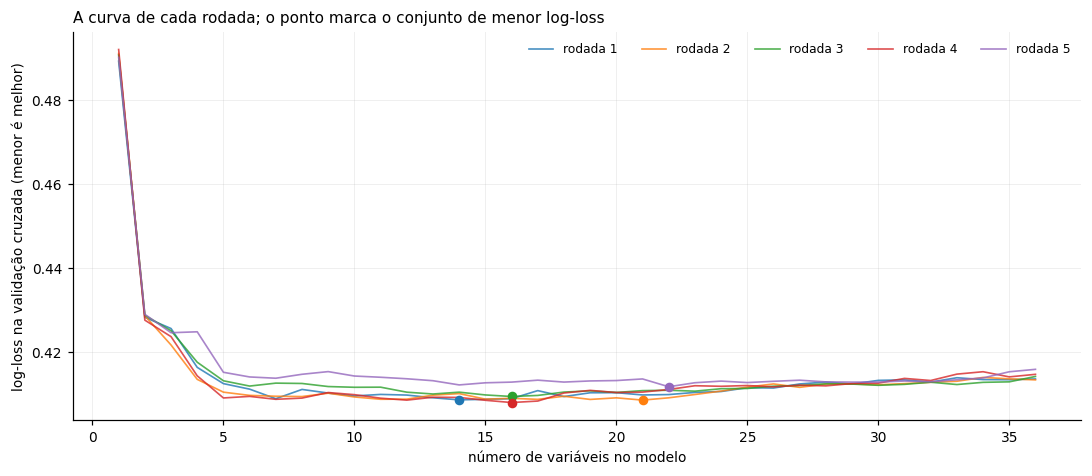

Tamanho do conjunto escolhido em cada rodada: 14 (rodada 1), 21 (rodada 2), 16 (rodada 3), 16 (rodada 4), 22 (rodada 5)


**A estabilidade de cada uma das 36 variáveis: entram as que ficam em pelo menos 4 das 5 rodadas**

| # | Variável | O que mede | Rodadas em que ficou no conjunto escolhido | Entra no modelo |
|---|---|---|---|---|
| 1 | `uf_rede_taxa_ant` | benchmark: mediana da mesma rede entre os municípios da UF | 5 de 5 | **sim** |
| 2 | `rede_taxa_ant` | taxa de alfabetização da rede do aluno no município | 5 de 5 | **sim** |
| 3 | `mun_participacao_ant` | percentual de alunos presentes na avaliação anterior | 5 de 5 | **sim** |
| 4 | `mun_populacao` | população do município | 5 de 5 | **sim** |
| 5 | `mun_pct_maes_adolescentes` | nascidos vivos de mãe com menos de 20 anos | 5 de 5 | **sim** |
| 6 | `esc_inse_medio` | nível socioeconômico médio das famílias atendidas pela rede | 5 de 5 | **sim** |
| 7 | `esc_horas_aula_diarias` | média de horas-aula diárias nos anos iniciais | 5 de 5 | **sim** |
| 8 | `mun_densidade_demografica` | habitantes por quilômetro quadrado | 5 de 5 | **sim** |
| 9 | `esc_pct_biblioteca_ou_sala_leitura` | escolas com biblioteca ou sala de leitura | 5 de 5 | **sim** |
| 10 | `mun_idade_mediana` | idade mediana da população | 5 de 5 | **sim** |
| 11 | `esc_pct_quadra` | escolas com quadra de esportes | 5 de 5 | **sim** |
| 12 | `mun_indice_pre_escola` | oferta de pré-escola diante dos anos iniciais, todas as redes do município | 4 de 5 | **sim** |
| 13 | `esc_pct_docentes_alto_esforco` | professores dos anos iniciais nos dois níveis mais altos de esforço | 4 de 5 | **sim** |
| 14 | `mun_pct_vulner_deslocamento_1h` | pessoas pobres que gastam mais de uma hora até o trabalho, aproximação das distâncias no território | 4 de 5 | **sim** |
| 15 | `mun_pct_maes_8_anos_estudo` | nascidos vivos cuja mãe tinha 8 anos de estudo ou mais | 3 de 5 | não |
| 16 | `mun_pct_servicos` | peso dos serviços, aproximação do caráter urbano da economia | 3 de 5 | não |
| 17 | `rede_vs_municipio` | posição da rede diante do seu município | 3 de 5 | não |
| 18 | `turma_media_alunos` | tamanho médio da turma do 2º ano, a série avaliada | 2 de 5 | não |
| 19 | `esc_pct_area_diferenciada` | escolas em terra indígena, quilombo, assentamento ou comunidade tradicional | 2 de 5 | não |
| 20 | `esc_pct_internet` | escolas com acesso à internet | 2 de 5 | não |
| 21 | `esc_pct_esgoto_rede` | escolas com esgotamento sanitário pela rede pública | 1 de 5 | não |
| 22 | `esc_pct_agua_rede` | escolas com abastecimento de água pela rede pública | 1 de 5 | não |
| 23 | `rede_peso_no_municipio` | fração dos alunos do município atendida pela rede | 1 de 5 | não |
| 24 | `mun_gini` | desigualdade na distribuição da renda | 1 de 5 | não |
| 25 | `esc_pct_rural` | alunos do 2º ano que estudam em escolas de zona rural | 1 de 5 | não |
| 26 | `esc_alunos_por_sala` | densidade física da rede: alunos por sala em uso, na falta de metragem | 1 de 5 | não |
| 27 | `mun_pct_agua_rede_geral` | população em domicílio ligado à rede geral de água e que a usa como forma principal | 1 de 5 | não |
| 28 | `mun_expectativa_estudo` | expectativa de anos de estudo | 0 de 5 | não |
| 29 | `rede_nome` | rede de ensino que atende o aluno | 0 de 5 | não |
| 30 | `esc_pct_docentes_formacao_adequada` | disciplinas dos anos iniciais dadas por professor com a formação adequada | 0 de 5 | não |
| 31 | `esc_alunos_por_docente` | alunos dos anos iniciais por professor dos anos iniciais | 0 de 5 | não |
| 32 | `mun_pib_per_capita` | riqueza produzida por habitante | 0 de 5 | não |
| 33 | `mun_taxa_homicidio` | óbitos por agressão por cem mil habitantes, aproximação da exposição à violência | 0 de 5 | não |
| 34 | `esc_pct_transporte` | dependência de transporte escolar, aproximação da distância entre aluno e escola | 0 de 5 | não |
| 35 | `esc_pct_docentes_baixa_regularidade` | professores que permaneceram pouco tempo na mesma escola nos últimos anos | 0 de 5 | não |
| 36 | `esc_pct_lab_informatica` | escolas com laboratório de informática | 0 de 5 | não |


CONFERÊNCIA NA VALIDAÇÃO CRUZADA DO TREINO
                             auc  log_loss  log_loss_desvio
as 41 do modelo anterior  0.8926    0.4122           0.0128
as 36 da etapa A          0.8914    0.4136           0.0130
as 14 selecionadas        0.8936    0.4097           0.0110

Tempo total: 1333 s. Registro da curadoria em reports/curadoria_variaveis.csv


In [79]:
# --- 2.3 Etapa B: ficar com as variáveis que ajudam a prever, de forma estável ---
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import GroupKFold

SEMENTE = 42
RODADAS = 5
MINIMO_RODADAS = 4           # a variável entra se estiver no conjunto escolhido em 4 das 5 rodadas
REPETICOES_EMBARALHAMENTO = 2
# a configuração da primeira versão do modelo da rede, fixa aqui: a seção 3 reescreve o registro do modelo
parametros_instrumento = {"min_samples_leaf": 10, "max_leaf_nodes": 15, "max_iter": 200,
                          "learning_rate": 0.02, "l2_regularization": 0.1}
treino_X, treino_y = treino_redes[VARIAVEIS], treino_redes["bateu_meta"]


def instrumento(variaveis: list) -> Pipeline:
    return montar_modelo(HistGradientBoostingClassifier(
        random_state=SEMENTE, early_stopping=False, **parametros_instrumento), False, variaveis)


def colunas_de(variavel: str, colunas: list) -> list:
    """As colunas da matriz preparada que vêm de uma variável: ela, o indicador de ausência e o one-hot."""
    indicadores = [n for n, v in INDICADORES.items() if v == variavel]
    return [c for c in colunas if c == variavel or c in indicadores or c.startswith(variavel + "_")]


def passo(variaveis: list, dobras: list, gerador) -> tuple:
    """Log-loss de cada parte com estas variáveis, e quanto cada uma faz falta quando embaralhada."""
    perdas, falta = [], {v: [] for v in variaveis}
    for i_treino, i_medir in dobras:
        modelo = instrumento(variaveis).fit(treino_X.iloc[i_treino], treino_y.iloc[i_treino])
        preparada = modelo.named_steps["preparo"].transform(treino_X.iloc[i_medir])
        arvores, y_medir = modelo.named_steps["modelo"], treino_y.iloc[i_medir]
        prever = lambda X: np.clip(arvores.predict_proba(X)[:, 1], 1e-6, 1 - 1e-6)
        base = log_loss(y_medir, prever(preparada))
        perdas.append(base)
        for v in variaveis:
            colunas = colunas_de(v, list(preparada.columns))
            for _ in range(REPETICOES_EMBARALHAMENTO):
                embaralhada = preparada.copy()
                embaralhada[colunas] = embaralhada[colunas].to_numpy()[gerador.permutation(len(embaralhada))]
                falta[v].append(log_loss(y_medir, prever(embaralhada)) - base)
    return np.array(perdas), pd.Series({v: np.mean(f) for v, f in falta.items()})


def eliminar(semente: int) -> pd.DataFrame:
    """Uma rodada completa de eliminação passo a passo, com a sua própria divisão e embaralhamento."""
    dobras = list(GroupKFold(n_splits=5, shuffle=True, random_state=semente)
                  .split(treino_X, treino_y, groups=treino_redes["id_municipio"]))
    gerador = np.random.default_rng(semente)
    atuais, curva = list(VARIAVEIS_ETAPA_A), []
    while atuais:
        perdas, falta = passo(atuais, dobras, gerador)
        curva.append({"variaveis": len(atuais), "log_loss": perdas.mean(), "desvio": perdas.std(ddof=1),
                      "sai": falta.idxmin(), "falta_que_faz": falta.min(), "conjunto": list(atuais)})
        atuais.remove(falta.idxmin())
    return pd.DataFrame(curva).set_index("variaveis").sort_index()


inicio = time.time()
rodadas = {}
for r in range(RODADAS):
    rodadas[r + 1] = eliminar(SEMENTE + r)
    print(f"  rodada {r + 1}: {time.time() - inicio:.0f} s")

# Em cada rodada, o conjunto de menor log-loss
escolhidos = {r: curva.loc[curva["log_loss"].idxmin(), "conjunto"] for r, curva in rodadas.items()}
frequencia = pd.Series(0, index=VARIAVEIS_ETAPA_A)
for conjunto in escolhidos.values():
    frequencia[conjunto] += 1
# até que passo cada variável sobreviveu, em média (maior = saiu mais tarde)
sobrevivencia = pd.DataFrame({r: {linha["sai"]: n for n, linha in curva.iterrows()}
                              for r, curva in rodadas.items()}).mean(axis=1)
VARIAVEIS_SELECIONADAS = [v for v in sobrevivencia.sort_values().index if frequencia[v] >= MINIMO_RODADAS]

fig, eixo = plt.subplots(figsize=(10, 4.4))
for r, curva in rodadas.items():
    eixo.plot(curva.index, curva["log_loss"], lw=1.1, alpha=.8, label=f"rodada {r}")
    melhor = curva["log_loss"].idxmin()
    eixo.scatter([melhor], [curva.loc[melhor, "log_loss"]], s=28, zorder=3)
eixo.set_xlabel("número de variáveis no modelo")
eixo.set_ylabel("log-loss na validação cruzada (menor é melhor)")
eixo.set_title("A curva de cada rodada; o ponto marca o conjunto de menor log-loss", fontsize=10, loc="left")
eixo.legend(fontsize=8, frameon=False, loc="upper right", ncol=5)
eixo.grid(alpha=.22, lw=.6)
plt.tight_layout()
plt.show()

print("Tamanho do conjunto escolhido em cada rodada: "
      + ", ".join(f"{len(c)} (rodada {r})" for r, c in escolhidos.items()))

nome = lambda v: DICIONARIO.loc[v, "descricao"] if v in DICIONARIO.index else v
# ordem: as mais estáveis primeiro; no empate, a que saiu mais tarde (menor número de variáveis restantes)
tabela = pd.DataFrame({"frequencia": frequencia, "sobrevivencia": sobrevivencia}).sort_values(
    ["frequencia", "sobrevivencia"], ascending=[False, True])
linhas_md = ["| # | Variável | O que mede | Rodadas em que ficou no conjunto escolhido | Entra no modelo |",
             "|---|---|---|---|---|"]
linhas_md += [f"| {k} | `{v}` | {nome(v)} | {int(t['frequencia'])} de {RODADAS} "
              f"| {'**sim**' if t['frequencia'] >= MINIMO_RODADAS else 'não'} |"
              for k, (v, t) in enumerate(tabela.iterrows(), start=1)]
display(Markdown(f"**A estabilidade de cada uma das {len(VARIAVEIS_ETAPA_A)} variáveis: entram as que ficam "
                 f"em pelo menos {MINIMO_RODADAS} das {RODADAS} rodadas**\n\n" + "\n".join(linhas_md)))

# Conferência: o conjunto selecionado contra o da etapa A e o anterior, na mesma validação cruzada
dobras_conferencia = list(GroupKFold(n_splits=5, shuffle=True, random_state=SEMENTE)
                          .split(treino_X, treino_y, groups=treino_redes["id_municipio"]))
conferencia = {}
for nome_conjunto, variaveis in [(f"as {len(VARIAVEIS_MODELO)} do modelo anterior", VARIAVEIS_MODELO),
                                 (f"as {len(VARIAVEIS_ETAPA_A)} da etapa A", VARIAVEIS_ETAPA_A),
                                 (f"as {len(VARIAVEIS_SELECIONADAS)} selecionadas", VARIAVEIS_SELECIONADAS)]:
    medidas = []
    for i_treino, i_medir in dobras_conferencia:
        p = instrumento(variaveis).fit(treino_X.iloc[i_treino], treino_y.iloc[i_treino]).predict_proba(
            treino_X.iloc[i_medir])[:, 1]
        medidas.append(medir(treino_y.iloc[i_medir], p))
    medidas = pd.DataFrame(medidas)
    conferencia[nome_conjunto] = {"auc": medidas["auc"].mean(), "log_loss": medidas["log_loss"].mean(),
                                  "log_loss_desvio": medidas["log_loss"].std(ddof=1)}
print()
print("CONFERÊNCIA NA VALIDAÇÃO CRUZADA DO TREINO")
print(pd.DataFrame(conferencia).T.round(4).to_string())

# O registro completo da curadoria: as variáveis do modelo anterior, em que etapa saíram e por quê
registro_curadoria = pd.DataFrame(
    [{"variavel": v, "etapa": "A", "situacao": "sai", "motivo": regra, "numero": valor} for v, regra, valor, _ in saidas]
    + [{"variavel": v, "etapa": "B", "situacao": "fica" if v in VARIAVEIS_SELECIONADAS else "sai",
        "motivo": "" if v in VARIAVEIS_SELECIONADAS else "pouco estável: fica em menos de 4 das 5 rodadas",
        "numero": f"{int(frequencia[v])} de {RODADAS} rodadas"} for v in VARIAVEIS_ETAPA_A])
registro_curadoria.to_csv("../reports/curadoria_variaveis.csv", index=False, encoding="utf-8")
print()
print(f"Tempo total: {time.time() - inicio:.0f} s. Registro da curadoria em reports/curadoria_variaveis.csv")

**Leitura.**

**Ficam 14 variáveis.** Onze aparecem no melhor conjunto das cinco rodadas, e três em quatro delas. Das 41 do modelo anterior, 5 saíram por redundância na etapa A e 22 por não fazerem diferença estável na etapa B.

**Enxugar não custa nada.** Na mesma validação cruzada, as 14 alcançam AUC de 0,8936 e log-loss de 0,4097, contra 0,8926 e 0,4122 das 41. É um empate, com leve vantagem para o conjunto menor: as 27 variáveis que saíram não acrescentavam informação que o modelo conseguisse usar.

**As cinco curvas contam a mesma história.** Em todas, o desempenho melhora muito até umas cinco variáveis e depois fica plano. O melhor ponto de cada rodada cai entre 14 e 22 variáveis, mas o núcleo é o mesmo. É isso que a seleção por estabilidade captura: a ordem muda de rodada para rodada, e as variáveis que importam continuam lá.

**As 14, por tema:**

| tema | variáveis |
|---|---|
| desempenho em 2023 | taxa da rede, taxa da mesma rede na UF |
| qualidade da medição | participação na avaliação de 2023 |
| porte e território | população, densidade, idade mediana, pobres com mais de 1 hora de deslocamento |
| família e primeira infância | nível socioeconômico das famílias, mães adolescentes, oferta de pré-escola |
| escola | horas-aula, biblioteca, quadra, professores com alto esforço |

**O que saiu e chama atenção.** O tipo de rede, municipal ou estadual, não ficou em nenhuma rodada: com as demais condições no modelo, ele não acrescenta. O mesmo vale para homicídios, PIB, formação dos professores e transporte escolar. Isso não quer dizer que esses fatores não importem para a alfabetização. Quer dizer que, para prever se a rede cumpre a meta, a informação deles já está nas 14 que ficaram.

⚠️ **Duas que ficaram e pedem cuidado.** A idade mediana da população entrou nas cinco rodadas sem uma hipótese própria: ela provavelmente marca a diferença demográfica entre regiões, já que o Sul e o Sudeste têm população mais velha, e faz o papel do território, que ficou fora desta seleção e volta ao modelo na seção 3 (D-015). O deslocamento de 1 hora é de 2010 e do município. As duas ficam, porque o critério é objetivo, mas devem ser lidas como marcas do território, e não como alavancas.

📌 **Consequência para a seção 3.** A busca de hiperparâmetros e a escolha da família passam a ser feitas sobre essas 14 variáveis.

## 3. Modelos no nível da rede

**Passos desta seção:** (3.1) montar a validação cruzada nas redes e medir as referências; (3.2) buscar os hiperparâmetros das três famílias; (3.3) escolher pelo critério declarado e confirmar na validação.

| Referência | O que faz |
|---|---|
| constante | dá a todas as redes a fração de redes que bateram a meta no treino |
| só a taxa de 2023 | regressão logística com uma única variável, a taxa da rede em 2023: é a versão probabilística de repetir o ano anterior |

📌 **Sem limite de empates.** No desenv_03, os alunos da mesma rede empatavam, e isso limitava a AUC. Na rede, cada linha tem uma única resposta e uma única previsão: uma ordenação perfeita das redes é possível em princípio, e o que limita a AUC é só a informação das variáveis.

**As variáveis são as 14 selecionadas na seção 2, mais a UF e a região.** A busca de hiperparâmetros e a escolha da família são refeitas sobre elas, e não herdadas do modelo anterior.

**O critério de escolha**, declarado antes de rodar, é o do desenv_03: vence a menor log-loss na validação cruzada, e a regressão logística é preferida se ficar a menos de um desvio da vencedora, por ser mais simples e interpretável.

**Por que o território entra (D-015).** UF e região não mudam de um ano para o outro, e por isso funcionam como a inércia: ajudam a explicar quem permanece onde está, e não quem muda. Como a inércia, o território fica **no modelo**, como ponto de partida de cada rede, e fica **fora da análise das alavancas** no desenv_05. Uma variante **sem território**, só as 14 variáveis, entra na comparação, para mostrar o que ele acrescenta.

In [110]:
# --- 3.1 Validação cruzada nas redes e referências ---
# O modelo final: as 14 variáveis selecionadas mais o território, que entra como ponto de partida (D-015)
VARIAVEIS_FINAIS = VARIAVEIS_SELECIONADAS + TERRITORIO
from sklearn.base import clone
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold, ParameterSampler

SEMENTE = 42
DOBRAS = list(GroupKFold(n_splits=5, shuffle=True, random_state=SEMENTE)
              .split(Xr_treino, yr_treino, groups=municipio_treino))


def validar(modelo) -> dict:
    """Treina em quatro partes e mede na quinta; cada rede pesa igual."""
    por_dobra = []
    for i_treino, i_teste in DOBRAS:
        y_t = yr_treino.iloc[i_teste]
        if modelo is None:   # referência constante
            p = np.full(len(y_t), yr_treino.iloc[i_treino].mean())
        else:
            m = clone(modelo).fit(Xr_treino.iloc[i_treino], yr_treino.iloc[i_treino])
            p = m.predict_proba(Xr_treino.iloc[i_teste])[:, 1]
        por_dobra.append(medir(y_t, p))
    d = pd.DataFrame(por_dobra)
    return {"auc": d["auc"].mean(), "auc_desvio": d["auc"].std(),
            "log_loss": d["log_loss"].mean(), "log_loss_desvio": d["log_loss"].std(),
            "brier": d["brier"].mean()}


SO_2023 = ["rede_taxa_ant"]
referencias = pd.DataFrame({
    "constante": validar(None),
    "só a taxa de 2023": validar(montar_modelo(LogisticRegression(max_iter=3000), True, SO_2023)),
    "logística, valores padrão": validar(montar_modelo(
        LogisticRegression(max_iter=3000), True, VARIAVEIS_FINAIS)),
}).T.astype(float)
print("AS CINCO PARTES DO TREINO")
print(pd.DataFrame([{"parte": k + 1, "municipios": municipio_treino.iloc[i].nunique(),
                     "redes": len(i), "bateram_pct": round(100 * yr_treino.iloc[i].mean(), 1)}
                    for k, (_, i) in enumerate(DOBRAS)]).set_index("parte").to_string())
print()
print("REFERÊNCIAS NA VALIDAÇÃO CRUZADA (cada rede pesa igual)")
print("=" * 86)
print(referencias.round(4).to_string())

AS CINCO PARTES DO TREINO
       municipios  redes  bateram_pct
parte                                
1             662    776         57.3
2             662    796         56.0
3             662    776         58.4
4             662    772         56.0
5             662    773         58.6

REFERÊNCIAS NA VALIDAÇÃO CRUZADA (cada rede pesa igual)
                              auc  auc_desvio  log_loss  log_loss_desvio   brier
constante                  0.5000      0.0000    0.6827           0.0037  0.2448
só a taxa de 2023          0.7873      0.0181    0.5488           0.0184  0.1833
logística, valores padrão  0.8885      0.0086    0.4163           0.0133  0.1335


regressão logística     10 combinações em 5 s
gradient boosting       12 combinações em 76 s
random forest           10 combinações em 49 s


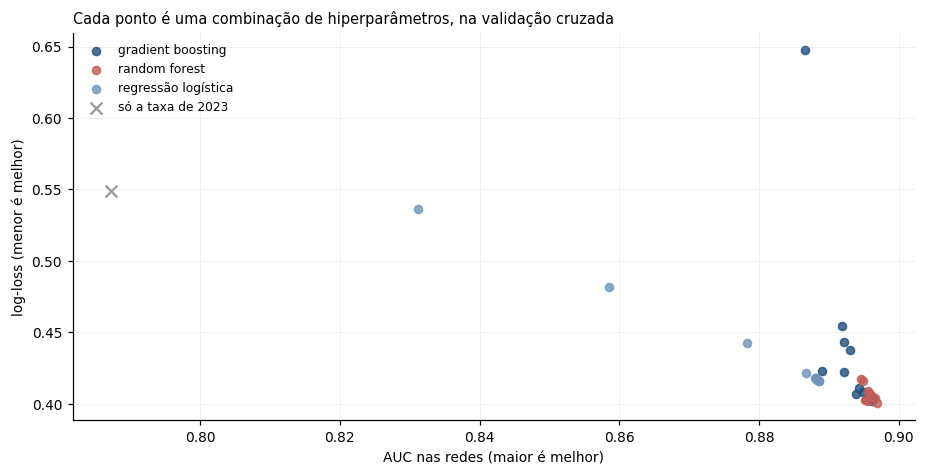


A MELHOR COMBINAÇÃO DE CADA FAMÍLIA, PELA LOG-LOSS
                        auc  auc_desvio  log_loss  log_loss_desvio   brier
familia                                                                   
random forest        0.8968      0.0080    0.4009           0.0108  0.1292
gradient boosting    0.8962      0.0086    0.4023           0.0137  0.1292
regressão logística  0.8886      0.0084    0.4159           0.0131  0.1334
  random forest          {'n_estimators': 400, 'min_samples_leaf': 5, 'max_features': 0.3, 'max_depth': 12}
  gradient boosting      {'min_samples_leaf': 20, 'max_leaf_nodes': 7, 'max_iter': 100, 'learning_rate': 0.1, 'l2_regularization': 0.0}
  regressão logística    {'C': 0.5994842503189409}


In [111]:
# --- 3.2 Busca de hiperparâmetros nas três famílias ---
FAMILIAS = {
    "regressão logística": {
        "linear": True, "combinacoes": 10,
        "fabrica": lambda p: LogisticRegression(max_iter=3000, **p),
        "espaco": {"C": [float(c) for c in np.logspace(-3, 2, 10)]}},
    "gradient boosting": {
        "linear": False, "combinacoes": 12,
        "fabrica": lambda p: HistGradientBoostingClassifier(
            random_state=SEMENTE, early_stopping=False, **p),
        "espaco": {"learning_rate": [0.02, 0.05, 0.1, 0.2], "max_iter": [100, 200, 400],
                   "max_leaf_nodes": [7, 15, 31, 63], "min_samples_leaf": [10, 20, 50, 100],
                   "l2_regularization": [0.0, 0.1, 1.0, 10.0]}},
    "random forest": {
        "linear": False, "combinacoes": 10,
        "fabrica": lambda p: RandomForestClassifier(random_state=SEMENTE, n_jobs=-1, **p),
        "espaco": {"n_estimators": [200, 400], "max_depth": [None, 8, 12, 20],
                   "min_samples_leaf": [2, 5, 10, 20, 50], "max_features": ["sqrt", 0.3, 0.5]}},
}

linhas = []
for familia, f in FAMILIAS.items():
    inicio = time.time()
    for parametros in ParameterSampler(f["espaco"], n_iter=f["combinacoes"], random_state=SEMENTE):
        linhas.append({"familia": familia, "parametros": parametros,
                       **validar(montar_modelo(f["fabrica"](parametros), f["linear"],
                                               VARIAVEIS_FINAIS))})
    print(f"{familia:<22} {f['combinacoes']:>3} combinações em {time.time() - inicio:.0f} s")

busca = pd.DataFrame(linhas)
busca.assign(parametros=busca["parametros"].map(json.dumps)).to_csv(
    "../reports/busca_hiperparametros_rede.csv", index=False, encoding="utf-8")
melhores = (busca.loc[busca.groupby("familia")["log_loss"].idxmin()]
            .set_index("familia").sort_values("log_loss"))

cores = {"regressão logística": "#6f94b8", "gradient boosting": "#1f4e79", "random forest": "#c25b56"}
fig, eixo = plt.subplots(figsize=(8.5, 4.4))
for familia, d in busca.groupby("familia"):
    eixo.scatter(d["auc"], d["log_loss"], s=28, alpha=.8, color=cores[familia], label=familia)
eixo.scatter(referencias.loc["só a taxa de 2023", "auc"], referencias.loc["só a taxa de 2023", "log_loss"],
             marker="x", s=60, color="#9a9a9a", label="só a taxa de 2023")
eixo.set_xlabel("AUC nas redes (maior é melhor)")
eixo.set_ylabel("log-loss (menor é melhor)")
eixo.set_title("Cada ponto é uma combinação de hiperparâmetros, na validação cruzada",
               fontsize=9.5, loc="left")
eixo.legend(fontsize=8, frameon=False)
eixo.grid(alpha=.22, lw=.6)
plt.tight_layout()
plt.show()

print()
print("A MELHOR COMBINAÇÃO DE CADA FAMÍLIA, PELA LOG-LOSS")
print("=" * 96)
print(melhores[["auc", "auc_desvio", "log_loss", "log_loss_desvio", "brier"]]
      .astype(float).round(4).to_string())
for familia, linha in melhores.iterrows():
    print(f"  {familia:<22} {linha['parametros']}")

In [112]:
# --- 3.3 Escolha pelo critério declarado e confirmação na validação ---
vencedora = melhores["log_loss"].idxmin()
distancia = melhores.loc["regressão logística", "log_loss"] - melhores.loc[vencedora, "log_loss"]
simples_serve = distancia <= melhores.loc[vencedora, "log_loss_desvio"]
escolhida = "regressão logística" if simples_serve else vencedora

print(f"Menor log-loss na validação cruzada: {vencedora} "
      f"({melhores.loc[vencedora, 'log_loss']:.4f}, desvio {melhores.loc[vencedora, 'log_loss_desvio']:.4f})")
print(f"Regressão logística: {distancia:+.4f} de log-loss em relação à vencedora")
print(f"Família escolhida: {escolhida}")
print()


def fabricar(familia: str, variaveis: list | None = None) -> Pipeline:
    """Pipeline da família com os hiperparâmetros escolhidos; as 14 e o território, por padrão."""
    f = FAMILIAS[familia]
    return montar_modelo(f["fabrica"](melhores.loc[familia, "parametros"]), f["linear"],
                         variaveis if variaveis is not None else VARIAVEIS_FINAIS)


candidatos = {f: fabricar(f).fit(Xr_treino, yr_treino) for f in melhores.index}
candidatos["só a taxa de 2023"] = montar_modelo(
    LogisticRegression(max_iter=3000), True, SO_2023).fit(Xr_treino, yr_treino)

# Variante sem território: quanto a UF e a região acrescentam ao modelo?
cv_sem_territorio = validar(fabricar(escolhida, VARIAVEIS_SELECIONADAS))
candidatos["sem território"] = fabricar(escolhida, VARIAVEIS_SELECIONADAS).fit(Xr_treino, yr_treino)
print(f"Sem UF e região: AUC {cv_sem_territorio['auc']:.4f} na validação cruzada, contra "
      f"{melhores.loc[escolhida, 'auc']:.4f} do modelo com território "
      f"(o território acrescenta {melhores.loc[escolhida, 'auc'] - cv_sem_territorio['auc']:+.4f})")
print()
prob_validacao = {nome: m.predict_proba(Xr_validacao)[:, 1] for nome, m in candidatos.items()}

estaveis = (alunos_validacao >= MIN_ALUNOS_ESTAVEL).to_numpy()
validacao = pd.DataFrame({nome: {
    **medir(yr_validacao, p),
    "auc_redes_20_alunos_ou_mais": roc_auc_score(yr_validacao[estaveis], p[estaveis]),
} for nome, p in prob_validacao.items()}).T.astype(float).sort_values("auc", ascending=False)
print(f"PARTIÇÃO DE VALIDAÇÃO ({len(yr_validacao):,} redes, {int(estaveis.sum()):,} com "
      f"{MIN_ALUNOS_ESTAVEL} alunos ou mais)")
print("=" * 104)
print(validacao.round(4).to_string())

registro = {
    "alvo": f"a rede bateu a meta nacional de 2024 ({META_2024}%)",
    "familia": escolhida, "parametros": melhores.loc[escolhida, "parametros"],
    "criterio": "menor log-loss na validação cruzada; a regressão logística vence "
                "se ficar a menos de um desvio da melhor",
    "selecao_de_variaveis": "etapa A (redundância) e etapa B (seleção por estabilidade), seção 2",
    "validacao_cruzada": {k: round(float(melhores.loc[escolhida, k]), 5)
                          for k in ["auc", "auc_desvio", "log_loss", "log_loss_desvio", "brier"]},
    "validacao": {k: round(float(validacao.loc[escolhida, k]), 5)
                  for k in ["auc", "log_loss", "brier", "auc_redes_20_alunos_ou_mais"]},
    "semente": SEMENTE, "variaveis": VARIAVEIS_FINAIS,
}
Path("../reports/modelo_rede_escolhido.json").write_text(
    json.dumps(registro, ensure_ascii=False, indent=2), encoding="utf-8")
print()
print("Registrado em reports/modelo_rede_escolhido.json")

# Quantas redes estão perto da linha da meta, onde um erro pequeno troca o lado da classificação
print()
taxa_validacao = redes.loc[redes["particao"] == "validacao", "taxa_real"]
for faixa in [3, 5]:
    perto = ((taxa_validacao - META_2024).abs() <= faixa).mean()
    print(f"Redes com taxa a menos de {faixa} pontos da meta de {META_2024}%: {perto:.1%}")


Menor log-loss na validação cruzada: random forest (0.4009, desvio 0.0108)
Regressão logística: +0.0151 de log-loss em relação à vencedora
Família escolhida: random forest

Sem UF e região: AUC 0.8891 na validação cruzada, contra 0.8968 do modelo com território (o território acrescenta +0.0078)

PARTIÇÃO DE VALIDAÇÃO (1,312 redes, 1,195 com 20 alunos ou mais)
                        auc  log_loss   brier  auc_redes_20_alunos_ou_mais
random forest        0.9113    0.3745  0.1182                       0.9247
gradient boosting    0.9058    0.3829  0.1213                       0.9203
regressão logística  0.9035    0.3897  0.1220                       0.9199
sem território       0.9015    0.3999  0.1267                       0.9159
só a taxa de 2023    0.7951    0.5486  0.1805                       0.8205

Registrado em reports/modelo_rede_escolhido.json

Redes com taxa a menos de 3 pontos da meta de 59.9%: 10.6%
Redes com taxa a menos de 5 pontos da meta de 59.9%: 18.1%


**Leitura.**

**Com o território, as três famílias sobem e ficam próximas.** Na validação cruzada, a Random Forest alcança 0,897 de AUC, o gradient boosting 0,896 e a regressão logística 0,889. Quem mais ganha é a logística, que estava em 0,815 sem o território: ela só enxerga relações em linha reta e dependia da UF para acertar o patamar de cada estado.

**A escolha, pelo critério declarado antes de rodar.** A menor log-loss é a da **Random Forest** (0,401), e a logística fica a 0,015 dela, acima do desvio de 0,011 entre as partes, então não tem a preferência. A Random Forest e o gradient boosting ficam praticamente empatados (0,401 contra 0,402), e o critério fica com a de menor log-loss. A configuração escolhida tem 400 árvores de até 12 níveis, no mínimo 5 redes por folha, e cada divisão sorteia 30% das variáveis.

**O território acrescenta mais do que antes.** Sem UF e região, a AUC cai de 0,897 para 0,889 na validação cruzada, uma perda de 0,008. Com as 41 variáveis antigas, a perda era de 0,003. A curadoria tirou variáveis que carregavam parte da diferença entre regiões, e essa informação agora vem da própria UF.

**Na partição de validação**, o modelo escolhido confirma a ordem: 0,911 de AUC, à frente das outras famílias e da variante sem território.

📌 **Consequência para a seção 4.** A Random Forest com as 14 variáveis e o território é treinada de novo com treino e validação juntos e medida no teste.

## 4. Avaliação no teste

**Passos desta seção:** (4.1) treinar o modelo final e medir no teste; (4.2) conferir a ordenação e a calibração; (4.3) comparar o cumpriu ou não cumpriu previsto com o real, na matriz de confusão; (4.4) medir por recorte.

Escolhido o modelo, ele é treinado de novo com o treino e a validação juntos, 80% dos municípios, porque mais dados melhoram a estimativa; os hiperparâmetros são os escolhidos na seção 3. Ao lado dele, são medidas a variante sem território e a referência do ano anterior. A partição de teste, 20% dos municípios, é aberta pela primeira vez aqui.

In [113]:
# --- 4.1 O modelo final no teste ---
modelos = {"modelo final": fabricar(escolhida).fit(Xr_final, yr_final),
           "sem território": fabricar(escolhida, VARIAVEIS_SELECIONADAS).fit(Xr_final, yr_final),
           "só a taxa de 2023": montar_modelo(LogisticRegression(max_iter=3000), True,
                                              SO_2023).fit(Xr_final, yr_final)}
prob = {nome: m.predict_proba(Xr_teste)[:, 1] for nome, m in modelos.items()}
prob["constante"] = np.full(len(yr_teste), yr_final.mean())

estaveis_teste = (alunos_teste >= MIN_ALUNOS_ESTAVEL).to_numpy()
ORDEM = ["constante", "só a taxa de 2023", "sem território", "modelo final"]
teste = pd.DataFrame({nome: {
    **medir(yr_teste, prob[nome]),
    "auc_redes_20_alunos_ou_mais": roc_auc_score(yr_teste[estaveis_teste], prob[nome][estaveis_teste]),
} for nome in ORDEM}).T.astype(float)
print(f"PARTIÇÃO DE TESTE ({len(yr_teste):,} redes, {int(alunos_teste.sum()):,} alunos, "
      f"{municipio_teste.nunique():,} municípios que nenhuma etapa viu)")
print("=" * 104)
print(teste.round(4).to_string())
print()
print(f"Esperado pela partição de validação: AUC {registro['validacao']['auc']:.3f}   ·   "
      f"obtido no teste: AUC {teste.loc['modelo final', 'auc']:.3f}")
teste.round(5).to_csv("../reports/avaliacao_teste_rede.csv", encoding="utf-8")

PARTIÇÃO DE TESTE (1,330 redes, 311,794 alunos, 1,104 municípios que nenhuma etapa viu)
                      auc  log_loss   brier  auc_redes_20_alunos_ou_mais
constante          0.5000    0.6833  0.2451                       0.5000
só a taxa de 2023  0.7687    0.5693  0.1922                       0.7923
sem território     0.8766    0.4377  0.1417                       0.8862
modelo final       0.8856    0.4169  0.1359                       0.8948

Esperado pela partição de validação: AUC 0.911   ·   obtido no teste: AUC 0.886


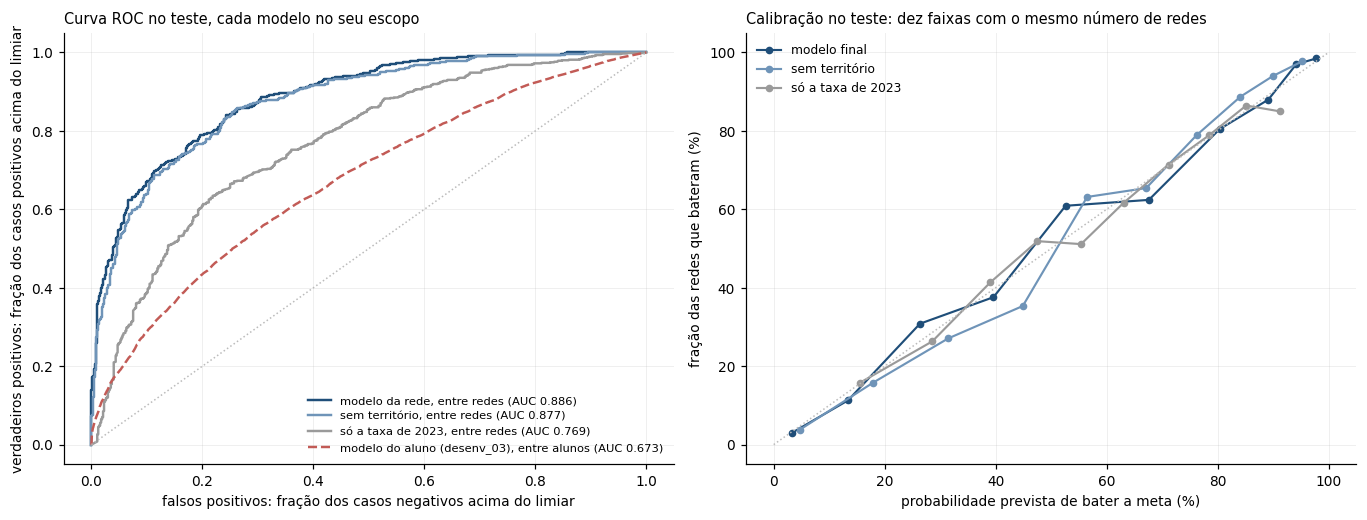

modelo final       maior distância entre prevista e observada numa faixa:  8.3 pp
sem território     maior distância entre prevista e observada numa faixa:  9.6 pp
só a taxa de 2023  maior distância entre prevista e observada numa faixa:  6.3 pp

NO GRÃO DO ALUNO, NO TESTE (311,794 alunos): AUC entre alunos
  modelo do aluno (desenv_03)    0.6726
  repetir 2023                   0.6429
  AUC máxima possível            0.7009


In [114]:
# --- 4.2 Ordenação e calibração no teste ---
from sklearn.metrics import roc_curve

# O modelo do aluno do desenv_03, no seu próprio escopo: cada aluno do teste recebe a probabilidade de
# ser alfabetizado. É treinado com a receita registrada (modelo_escolhido.json), nos alunos do treino e da
# validação, pelos grupos de município e rede, como no desenv_03.
alunos_final = abt[abt["particao"].isin(["treino", "validacao"])]
grupos = alunos_final.groupby(["id_municipio", "rede_nome"], observed=True).agg(
    alfabetizados=("alvo", "sum"), alunos=("alvo", "size"),
    **{v: (v, "first") for v in NUMERICAS + ["sigla_uf", "nome_regiao"]}).reset_index()
linhas_aluno = pd.concat([grupos.assign(y=1, w=grupos["alfabetizados"]),
                          grupos.assign(y=0, w=grupos["alunos"] - grupos["alfabetizados"])]).query("w > 0")
modelo_do_aluno = montar_modelo(LogisticRegression(max_iter=3000, **modelo_aluno["parametros"]), True)
modelo_do_aluno.fit(linhas_aluno[VARIAVEIS], linhas_aluno["y"],
                    modelo__sample_weight=(linhas_aluno["w"] / linhas_aluno["w"].mean()).to_numpy())

# Os alunos do teste: cada rede vira duas linhas, alfabetizados e não alfabetizados, pesadas pelo número de alunos
redes_teste = redes[redes["particao"] == "teste"]
y_alunos = np.r_[np.ones(len(redes_teste)), np.zeros(len(redes_teste))]
peso_alunos = np.r_[redes_teste["alfabetizados"], redes_teste["alunos"] - redes_teste["alfabetizados"]]
por_aluno = lambda nota: np.r_[np.asarray(nota), np.asarray(nota)]
notas_aluno = {
    "modelo do aluno (desenv_03)": modelo_do_aluno.predict_proba(redes_teste[VARIAVEIS])[:, 1],
    "repetir 2023": redes_teste["rede_taxa_ant"].fillna(redes_teste["rede_taxa_ant"].median()),
    "AUC máxima possível": redes_teste["alfabetizados"] / redes_teste["alunos"],
}
auc_aluno = {nome: roc_auc_score(y_alunos, por_aluno(n), sample_weight=peso_alunos) for nome, n in notas_aluno.items()}

curvas = {"modelo final": "#1f4e79", "sem território": "#6f94b8", "só a taxa de 2023": "#9a9a9a"}
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.8))
calibracao = {}
for nome, cor in curvas.items():
    fp, vp, _ = roc_curve(yr_teste, prob[nome])
    rotulo = "modelo da rede" if nome == "modelo final" else nome
    ax1.plot(fp, vp, color=cor, lw=1.6, label=f"{rotulo}, entre redes (AUC {teste.loc[nome, 'auc']:.3f})")
    c = pd.DataFrame({"p": prob[nome], "y": yr_teste.to_numpy()}).sort_values("p")
    c["faixa"] = pd.qcut(np.arange(len(c)), 10, labels=False)
    g = c.groupby("faixa").agg(prevista=("p", "mean"), observada=("y", "mean"))
    calibracao[nome] = g
    ax2.plot(100 * g["prevista"], 100 * g["observada"], "o-", color=cor, lw=1.4, ms=4, label=nome)
fp, vp, _ = roc_curve(y_alunos, por_aluno(notas_aluno["modelo do aluno (desenv_03)"]), sample_weight=peso_alunos)
ax1.plot(fp, vp, color="#c25b56", lw=1.6, ls="--",
         label=f"modelo do aluno (desenv_03), entre alunos (AUC {auc_aluno['modelo do aluno (desenv_03)']:.3f})")
ax1.plot([0, 1], [0, 1], color="#bbb", ls=":", lw=1)
ax1.set_xlabel("falsos positivos: fração dos casos negativos acima do limiar")
ax1.set_ylabel("verdadeiros positivos: fração dos casos positivos acima do limiar")
ax1.set_title("Curva ROC no teste, cada modelo no seu escopo", fontsize=9.5, loc="left")
ax1.legend(fontsize=7.5, frameon=False, loc="lower right")
ax2.plot([0, 100], [0, 100], color="#bbb", ls=":", lw=1)
ax2.set_xlabel("probabilidade prevista de bater a meta (%)")
ax2.set_ylabel("fração das redes que bateram (%)")
ax2.set_title("Calibração no teste: dez faixas com o mesmo número de redes", fontsize=9.5, loc="left")
ax2.legend(fontsize=8, frameon=False, loc="upper left")
for eixo in (ax1, ax2):
    eixo.grid(alpha=.22, lw=.6)
plt.tight_layout()
plt.show()

for nome in curvas:
    g = calibracao[nome]
    print(f"{nome:<18} maior distância entre prevista e observada numa faixa: "
          f"{100 * (g['prevista'] - g['observada']).abs().max():4.1f} pp")
print()
print(f"NO GRÃO DO ALUNO, NO TESTE ({int(peso_alunos.sum()):,} alunos): AUC entre alunos")
for nome, valor in auc_aluno.items():
    print(f"  {nome:<30} {valor:.4f}")

### 4.3 Cumpriu ou não cumpriu: a matriz de confusão

O modelo devolve uma probabilidade. Para classificar, a rede é prevista como **cumpriu a meta** quando a probabilidade é de 50% ou mais, e como **não cumpriu a meta** abaixo disso. A matriz de confusão cruza essa previsão com o que de fato aconteceu em 2024: nas linhas, os dados; nas colunas, o modelo. A diagonal são os acertos.

As medidas olham para as redes que não cumpriram a meta, que são as que o gestor precisa encontrar:

- **precisão:** das redes que o modelo previu que não cumpririam, quantas de fato não cumpriram;
- **sensibilidade:** das redes que não cumpriram, quantas o modelo previu;
- **acurácia:** quantas redes, no total, o modelo classificou corretamente.

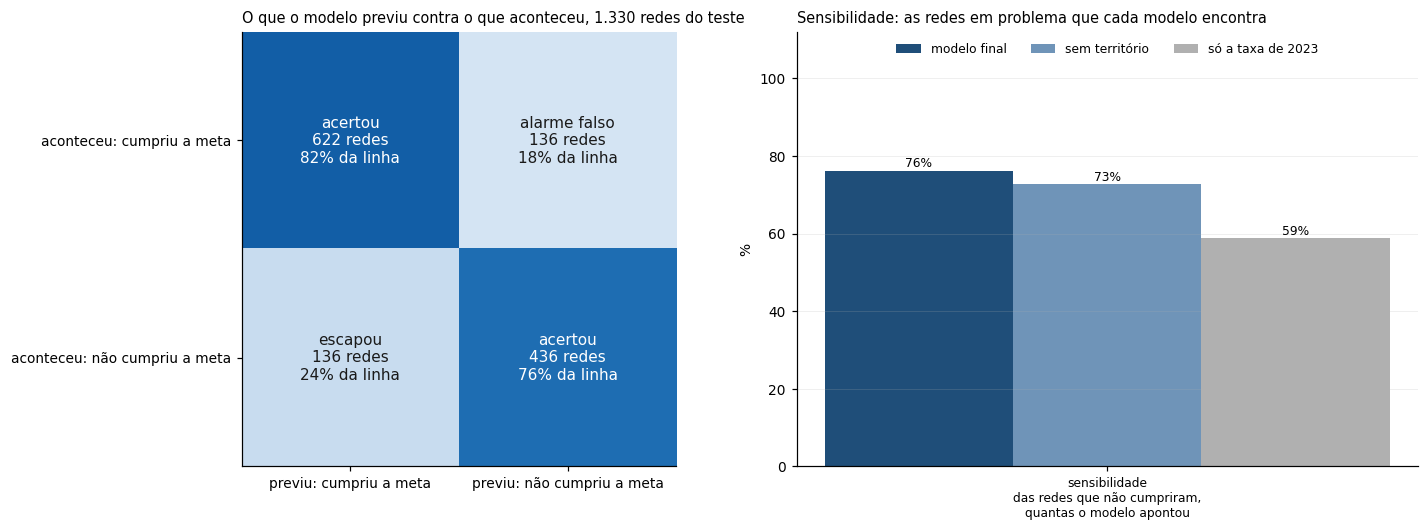

REDES DO TESTE: 1,330 · cumpriram a meta: 758 · não cumpriram: 572 (prever sempre a classe majoritária acerta 57.0%)

MATRIZ DE CONFUSÃO DO MODELO FINAL
                           modelo: cumpriu a meta  modelo: não cumpriu a meta
dados: cumpriu a meta                         622                         136
dados: não cumpriu a meta                     136                         436

MEDIDAS PARA 'NÃO CUMPRIU A META' (%)
                   precisão  sensibilidade  acurácia
modelo final           76.2           76.2      79.5
sem território         79.7           72.7      80.3
só a taxa de 2023      67.1           58.7      69.8


In [115]:
# --- 4.3 Cumpriu ou não cumpriu: a matriz de confusão, com o limiar de 50% ---
LIMIAR = 0.5
CLASSES = ["cumpriu a meta", "não cumpriu a meta"]
nao_cumpriu = (yr_teste == 0).to_numpy()   # dados: a taxa real de 2024 ficou abaixo de 59,9%


def medidas(nome: str) -> dict:
    """Precisão, sensibilidade e acurácia para 'não cumpriu a meta'."""
    previu_nao = prob[nome] < LIMIAR   # modelo: probabilidade de cumprir abaixo de 50%
    acertou_nao = (previu_nao & nao_cumpriu).sum()
    return {"precisão": 100 * acertou_nao / previu_nao.sum(),
            "sensibilidade": 100 * acertou_nao / nao_cumpriu.sum(),
            "acurácia": 100 * (previu_nao == nao_cumpriu).mean()}


def matriz_de_confusao(nome: str) -> pd.DataFrame:
    """Linhas: o que aconteceu (dados). Colunas: o que o modelo previu."""
    previu_nao = prob[nome] < LIMIAR
    return pd.DataFrame([[(~nao_cumpriu & ~previu_nao).sum(), (~nao_cumpriu & previu_nao).sum()],
                         [(nao_cumpriu & ~previu_nao).sum(), (nao_cumpriu & previu_nao).sum()]],
                        index=[f"dados: {c}" for c in CLASSES],
                        columns=[f"modelo: {c}" for c in CLASSES])


milhar = lambda v: f"{v:,}".replace(",", ".")   # separador de milhar em português
matriz = matriz_de_confusao("modelo final")
classificacao = pd.DataFrame({n: medidas(n) for n in ["modelo final", "sem território",
                                                      "só a taxa de 2023"]}).T
m = matriz.to_numpy()
pct = 100 * m / m.sum(axis=1, keepdims=True)
SIGNIFICADO = [["acertou", "alarme falso"], ["escapou", "acertou"]]

fig, (eixo, barras) = plt.subplots(1, 2, figsize=(13.5, 4.9), gridspec_kw={"width_ratios": [1.05, 1]})
eixo.imshow(pct, cmap="Blues", vmin=0, vmax=100)
for i in range(2):
    for j in range(2):
        eixo.text(j, i, f"{SIGNIFICADO[i][j]}\n{milhar(m[i, j])} redes\n{pct[i, j]:.0f}% da linha",
                  ha="center", va="center", fontsize=10, color="white" if pct[i, j] > 55 else "#1a1a1a")
eixo.set_xticks([0, 1], [f"previu: {c}" for c in CLASSES])
eixo.set_yticks([0, 1], [f"aconteceu: {c}" for c in CLASSES])
eixo.set_title(f"O que o modelo previu contra o que aconteceu, {milhar(len(nao_cumpriu))} redes do teste",
               fontsize=9.5, loc="left")

MEDIDAS = {"sensibilidade": "das redes que não cumpriram,\nquantas o modelo apontou"}
CORES = {"modelo final": "#1f4e79", "sem território": "#6f94b8", "só a taxa de 2023": "#b0b0b0"}
largura = 0.26
for k, (nome, cor) in enumerate(CORES.items()):
    valores = [classificacao.loc[nome, medida] for medida in MEDIDAS]
    posicoes = np.arange(len(MEDIDAS)) + (k - 1) * largura
    barras.bar(posicoes, valores, width=largura, color=cor, label=nome)
    for x, v in zip(posicoes, valores):
        barras.text(x, v + 1, f"{v:.0f}%", ha="center", fontsize=8)
barras.set_xticks(range(len(MEDIDAS)), [f"{medida}\n{explicacao}" for medida, explicacao in MEDIDAS.items()],
                  fontsize=8)
barras.set_ylim(0, 112)
barras.set_yticks(range(0, 101, 20))
barras.set_ylabel("%")
barras.set_title("Sensibilidade: as redes em problema que cada modelo encontra", fontsize=9.5, loc="left")
barras.legend(fontsize=8, frameon=False, loc="upper center", ncol=3)
barras.grid(alpha=.22, lw=.6, axis="y")
plt.tight_layout()
plt.show()

print(f"REDES DO TESTE: {len(nao_cumpriu):,} · cumpriram a meta: {int((~nao_cumpriu).sum()):,} · "
      f"não cumpriram: {int(nao_cumpriu.sum()):,} "
      f"(prever sempre a classe majoritária acerta {max(nao_cumpriu.mean(), 1 - nao_cumpriu.mean()):.1%})")
print()
print("MATRIZ DE CONFUSÃO DO MODELO FINAL")
print(matriz.to_string())
print()
print("MEDIDAS PARA 'NÃO CUMPRIU A META' (%)")
print(classificacao.round(1).to_string())


In [116]:
# --- 4.4 Por recorte ---
d_teste = redes[redes["particao"] == "teste"].assign(p=prob["modelo final"])


def por_recorte(rotulos: pd.Series) -> pd.DataFrame:
    linhas = []
    for valor in rotulos.dropna().unique():
        d = d_teste[(rotulos == valor).to_numpy()]
        linhas.append({
            "recorte": valor, "redes": len(d), "alunos": int(d["alunos"].sum()),
            "bateram_pct": 100 * d["bateu_meta"].mean(),
            "prob_media_prevista_pct": 100 * d["p"].mean(),
            "auc": roc_auc_score(d["bateu_meta"], d["p"]) if d["bateu_meta"].nunique() == 2 else np.nan,
        })
    t = pd.DataFrame(linhas).set_index("recorte")
    t["diferenca_pp"] = t["prob_media_prevista_pct"] - t["bateram_pct"]
    return t.round(3)


tamanho = pd.cut(d_teste["alunos"], [0, MIN_ALUNOS_ESTAVEL - 1, 100, 1000, np.inf],
                 labels=[f"menos de {MIN_ALUNOS_ESTAVEL}", f"{MIN_ALUNOS_ESTAVEL} a 100",
                         "101 a 1.000", "mais de 1.000"])
porte = pd.cut(d_teste["mun_populacao"], [0, 20_000, 100_000, np.inf],
               labels=["até 20 mil", "20 a 100 mil", "mais de 100 mil"])
recortes = {
    "ALUNOS AVALIADOS NA REDE": por_recorte(tamanho.astype(str)).reindex(tamanho.cat.categories),
    "PORTE DO MUNICÍPIO (habitantes)": por_recorte(porte.astype(str)).reindex(porte.cat.categories),
    "REGIÃO": por_recorte(d_teste["nome_regiao"]).sort_values("redes", ascending=False),
    "REDE": por_recorte(d_teste["rede_nome"]),
    "RIO GRANDE DO SUL": por_recorte(pd.Series(
        np.where(d_teste["sigla_uf"] == "RS", "RS", "demais UFs"), index=d_teste.index)),
}
for titulo, tabela in recortes.items():
    print(titulo)
    print(tabela.to_string())
    print()

ALUNOS AVALIADOS NA REDE
               redes  alunos  bateram_pct  prob_media_prevista_pct    auc  diferenca_pp
menos de 20      113    1595       54.867                   52.288  0.754        -2.579
20 a 100         591   32366       60.406                   61.837  0.865         1.431
101 a 1.000      569  153416       54.833                   52.531  0.916        -2.302
mais de 1.000     57  124417       47.368                   47.743  0.952         0.374

PORTE DO MUNICÍPIO (habitantes)
                 redes  alunos  bateram_pct  prob_media_prevista_pct    auc  diferenca_pp
até 20 mil         864   63944       62.153                   60.318  0.856        -1.835
20 a 100 mil       367  106386       46.049                   48.664  0.916         2.615
mais de 100 mil     99  141464       52.525                   51.430  0.955        -1.095

REGIÃO
              redes  alunos  bateram_pct  prob_media_prevista_pct    auc  diferenca_pp
recorte                                        

**Leitura.**

**No teste, o modelo final é o melhor de todas as versões.** Em 1.104 municípios que nenhuma etapa viu, a AUC é de 0,886 e a log-loss de 0,417. Sem o território, o mesmo modelo fica em 0,877, e repetir 2023 fica em 0,769.

**Curva ROC (figura da 4.2).** A curva do modelo da rede fica bem acima da de repetir 2023, e a variante sem território quase se sobrepõe a ela. A curva tracejada é a do modelo do aluno do desenv_03, traçada entre alunos, no seu próprio escopo: 0,673 de AUC no teste, perto dos 0,701 que são o máximo possível naquele grão. Ela fica abaixo das outras porque a tarefa dela é separar alunos com variáveis que são iguais para todos os alunos da mesma rede.

**Calibração.** A maior distância entre a probabilidade prevista e a fração observada numa faixa é de 8,3 pontos, melhor que os 9,6 da variante sem território, mas ainda acima dos 6,3 de repetir 2023. As probabilidades servem bem para ordenar as redes, e com alguma folga como número.

**Cumpriu ou não cumpriu (figura da 4.3).** Os dois erros da matriz têm exatamente o mesmo tamanho, 136 redes cada, e o limiar de 50% não favorece nenhum dos lados. A sensibilidade é de 76%: de cada quatro redes que ficaram abaixo da meta, o modelo encontra três. Sem o território, 73%; repetindo 2023, 59%, porque a referência nunca antecipa uma queda.

**Por recorte:**

1. **quanto maior a rede, melhor o modelo:** a AUC vai de 0,754 nas redes com menos de 20 alunos a 0,952 nas com mais de mil;
2. **o Norte continua subestimado em 11 pontos,** mesmo com a UF no modelo. A região tem poucas redes, e as árvores não chegam a aprender o patamar dela; a ordenação dentro da região, porém, é boa (0,844);
3. **a rede estadual segue mais difícil** (0,837, contra 0,895 da municipal). O Rio Grande do Sul fica em 0,777, mas agora com o patamar certo: o modelo prevê 34,6% e observa 35,0%.

---

## Parecer final: o modelo da rede

**A pergunta.** A rede, municipal ou estadual, de cada município vai cumprir a meta nacional de 2024, de 59,9% de crianças alfabetizadas? O modelo devolve a probabilidade de cumprir. A meta é a pactuada no Compromisso Nacional Criança Alfabetizada; o país, em 2024, ficou em 59,2%, logo abaixo dela.

**O que foi feito, em três passos:**

1. **Curadoria das variáveis (seção 2).** As variáveis herdadas do grão do aluno passaram por dois filtros objetivos, calculados só no treino: a etapa A tirou as redundantes sem olhar a resposta, e a etapa B, uma eliminação passo a passo repetida em cinco rodadas, manteve as que ficam no melhor conjunto em pelo menos quatro delas. Ficaram 14. A UF e a região ficaram fora da seleção e entram no modelo como ponto de partida, a exemplo da inércia, porque não mudam de um ano para o outro (D-015).
2. **Escolha do modelo (seção 3).** Três famílias foram comparadas com o critério declarado antes de rodar. Venceu a Random Forest, praticamente empatada com o gradient boosting.
3. **Avaliação no teste (seção 4).** O modelo foi medido em 1.104 municípios que nenhuma etapa viu.

**A referência: repetir 2023.** Para saber se um modelo acrescenta alguma coisa, ele é comparado com o que se faria sem modelo: supor que cada rede repete a situação do ano anterior. Na prática, é uma regressão logística com uma única variável, a taxa da rede em 2023: quanto maior essa taxa, maior a chance prevista de cumprir a meta em 2024. É uma referência exigente, porque a taxa de um ano explica boa parte da do ano seguinte, e um modelo que não a supera não serve para decidir. No desenv_03, a mesma ideia valia no grão do aluno: cada aluno recebia como nota a taxa da sua rede em 2023.

**O resultado, na partição de teste:**

| medida, no teste | modelo final | repetir 2023 |
|---|---|---|
| AUC: quem ordena melhor as redes | **0,886** | 0,769 |
| log-loss (menor é melhor) | **0,417** | 0,569 |
| sensibilidade: das redes que não cumpriram, quantas o modelo apontou | **76,2%** | 58,7% |
| maior erro de calibração numa faixa | 8,3 pp | 6,3 pp |

**A curadoria otimizou o modelo.** Com 14 variáveis e o território, ele prevê melhor do que com as 41 herdadas do desenv_03 (0,886 contra 0,877 de AUC no teste), e fica explicável.

**Por que a sensibilidade, e não a acurácia.** A meta de 59,9% está praticamente em cima da média do país, e 18% das redes ficam a menos de 5 pontos dela. Nessa faixa, um erro pequeno na previsão troca o lado da classificação, e a acurácia passa a medir a sorte na fronteira, e não a qualidade do modelo. Por isso o modelo é lido por dois prismas: a **AUC**, que mede se ele ordena bem as redes sem depender de limiar, e a **sensibilidade**, que mede quantas redes em problema ele encontra, que é o que importa para o gestor.

**A mudança de grão se sustenta?** Cada modelo, no seu próprio escopo, na partição de teste:

| no teste | desenv_03: o modelo do aluno | desenv_04: o modelo da rede |
|---|---|---|
| a pergunta | o aluno será alfabetizado? | a rede cumprirá a meta de 2024? |
| AUC | 0,673 | 0,886 |
| AUC de repetir 2023 | 0,643 | 0,769 |
| ganho sobre repetir 2023 | +0,030 | +0,117 |
| limite da tarefa | 0,701, a AUC máxima possível | sem limite estrutural |

No grão do aluno, o modelo ficava preso a um teto baixo: todas as variáveis são iguais para os alunos da mesma rede, e é entre esses alunos que está cerca de 90% da diferença de resultado. Ele ganhava pouco de repetir o ano anterior e não tinha para onde crescer. No grão da rede, as mesmas fontes descrevem exatamente a unidade prevista, e o modelo se distancia claramente da referência. As AUCs das duas tarefas não se comparam como número, mas mostram onde os dados têm informação: a mudança se sustenta.

**Parecer.** O modelo da rede é a entrega útil deste projeto. Ele ordena as redes com AUC de 0,886 em municípios nunca vistos, encontra três de cada quatro redes que não cumprem a meta e usa 14 variáveis mais o território. O modelo do aluno do desenv_03 continua sendo a resposta literal ao enunciado, com o seu limite medido; este é o que serve para decidir.

**As limitações, declaradas:**

1. **Calibração.** As probabilidades de algumas faixas ficaram até 8,3 pontos distantes do observado. Servem bem como ordem de prioridade e, com folga, como número.
2. **O Norte fica subestimado em 11 pontos,** mesmo com a UF no modelo: a região tem poucas redes, e as árvores não chegam a aprender o patamar dela. A ordenação dentro da região é boa.
3. **Casos difíceis:** redes com menos de 20 alunos, a rede estadual e o Rio Grande do Sul no ano das enchentes.
4. **Duas variáveis selecionadas são marcas do território,** e não alavancas: a idade mediana da população e o deslocamento de 1 hora, que é de 2010.
5. **O aluno continua indistinguível.** O modelo da rede contorna o limite do desenv_03 mudando a unidade de decisão, mas não o resolve.

**O que fica para o desenv_05,** que analisa o modelo pronto: quais fatores pesam e em que direção, com a inércia e o território como ponto de partida, fora da análise das alavancas; quais redes estão em risco e quanto falta para as metas; e quais redes se parecem entre si, respondendo às perguntas de negócio do enunciado.